# Read in the data

In [31]:
import pandas as pd

# indeed data
indeed_w1 = pd.read_csv("./new_data/Indeed_w1.csv", sep=",", skiprows=1)
indeed_w2 = pd.read_csv("./new_data/Indeed_w2.csv", sep=",", skiprows=1)
indeed_w3 = pd.read_csv("./new_data/Indeed_w3.csv", sep=",", skiprows=1)

# stepstone data
stepstone_w1 = pd.read_csv("./new_data/Stepstone_w1.csv", sep=",", skiprows=1)
stepstone_w2 = pd.read_csv("./new_data/Stepstone_w2.csv", sep=",", skiprows=1)
stepstone_w3 = pd.read_csv("./new_data/Stepstone_w3.csv", sep=",", skiprows=1)

# bewerbung data 
Bewerbung_w1 = pd.read_csv("./new_data/Bewerbung_w1.csv", sep=",", skiprows=1)
Bewerbung_w2 = pd.read_csv("./new_data/Bewerbung_w2.csv", sep=",", skiprows=1)
Bewerbung_w3 = pd.read_csv("./new_data/Bewerbung_w3.csv", sep=",", skiprows=1)

# arbeitsamt data
arbeitsamt_w1 = pd.read_csv("./new_data/Arbeitsamt_w1.csv", sep=",", skiprows=1)
arbeitsamt_w2 = pd.read_csv("./new_data/Arbeitsamt_w2.csv", sep=",", skiprows=1)
arbeitsamt_w3 = pd.read_csv("./new_data/Arbeitsamt_w3.csv", sep=",", skiprows=1)

# jobbörse data 
jobbörse_w1 = pd.read_csv("./new_data/Jobbörse_w1.csv", sep=",", skiprows=1)
jobbörse_w2 = pd.read_csv("./new_data/Jobbörse_w2.csv", sep=",", skiprows=1)
jobbörse_w3 = pd.read_csv("./new_data/Jobbörse_w3.csv", sep=",", skiprows=1)

## Define the columns for all
indeed_w1.columns = ["Date", "indeed"]
indeed_w2.columns = ["Date", "indeed"]
indeed_w3.columns = ["Date", "indeed"]

stepstone_w1.columns = ["Date", "stepstone"]
stepstone_w2.columns = ["Date", "stepstone"]
stepstone_w3.columns = ["Date", "stepstone"]

Bewerbung_w1.columns = ["Date","bewerbung"]
Bewerbung_w2.columns = ["Date","bewerbung"]
Bewerbung_w3.columns = ["Date","bewerbung"]

arbeitsamt_w1.columns = ["Date", "arbeitsamt"]
arbeitsamt_w2.columns = ["Date", "arbeitsamt"]
arbeitsamt_w3.columns = ["Date", "arbeitsamt"]

jobbörse_w1.columns = ["Date", "jobbörse"]
jobbörse_w2.columns = ["Date", "jobbörse"]
jobbörse_w3.columns = ["Date", "jobbörse"]






In [32]:
# ensure that they have the correct date format
for df in [indeed_w1,indeed_w2,indeed_w3, stepstone_w1, stepstone_w2, stepstone_w3, Bewerbung_w1,Bewerbung_w2,Bewerbung_w3, arbeitsamt_w1,arbeitsamt_w2,arbeitsamt_w3, jobbörse_w1, jobbörse_w2, jobbörse_w3]:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    df[df.columns[1]] = pd.to_numeric(df[df.columns[1]], errors="coerce")

## The big stitching

In [33]:
import numpy as np
import pandas as pd

START = pd.Timestamp("2011-05-01")      # Sunday
END_WEEK = pd.Timestamp("2023-01-29")   # Sunday
END_MONTH = pd.Timestamp("2023-01-31")  # Month-end label for monthly data

def _prep(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    out = df[["Date", value_col]].copy()
    out["Date"] = pd.to_datetime(out["Date"], errors="coerce").dt.tz_localize(None)
    out[value_col] = pd.to_numeric(out[value_col], errors="coerce")
    out = out.dropna(subset=["Date", value_col]).set_index("Date").sort_index()
    return out

def _median_ratio(a: pd.Series, b: pd.Series) -> float:
    idx = a.index.intersection(b.index)
    x, y = a.loc[idx], b.loc[idx]
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    return float(np.median((x[mask] / y[mask]).values)) if mask.sum() else 1.0

def stitch_three(w1: pd.DataFrame, w2: pd.DataFrame, w3: pd.DataFrame,
                 value_col: str, final_name: str | None = None) -> pd.DataFrame:
    W1 = _prep(w1, value_col)
    W2 = _prep(w2, value_col)
    W3 = _prep(w3, value_col)

    # rescale W2 to match W1 on overlap
    s21 = _median_ratio(W1[value_col], W2[value_col])
    W2r = W2.copy()
    W2r[value_col] = W2r[value_col] * s21

    # rescale W3 to match W2r on overlap
    s32 = _median_ratio(W2r[value_col], W3[value_col])
    W3r = W3.copy()
    W3r[value_col] = W3r[value_col] * s32

    # concatenate without duplicate dates (prefer earlier windows)
    out = pd.concat([
        W1,
        W2r.loc[~W2r.index.isin(W1.index)],
        W3r.loc[~W3r.index.isin(W1.index.union(W2r.index))]
    ]).sort_index()

    # trim to analysis window
    out = out.loc[(out.index >= START) & (out.index <= END_WEEK)].copy()

    name = final_name or value_col
    out = out.rename(columns={value_col: name}).reset_index().rename(columns={"index": "Date"})
    return out

# --- Build stitched weekly series from your already-loaded dataframes
indeed     = stitch_three(indeed_w1, indeed_w2, indeed_w3, "indeed")
stepstone  = stitch_three(stepstone_w1, stepstone_w2, stepstone_w3, "stepstone")
bewerbung  = stitch_three(Bewerbung_w1, Bewerbung_w2, Bewerbung_w3, "bewerbung")
arbeitsamt = stitch_three(arbeitsamt_w1, arbeitsamt_w2, arbeitsamt_w3, "arbeitsamt")
jobboerse  = stitch_three(jobbörse_w1, jobbörse_w2, jobbörse_w3, "jobbörse")

# --- Optional sanity
for name, d in [("indeed", indeed), ("stepstone", stepstone), ("jobbörse", jobboerse), ("arbeitsamt", arbeitsamt), ("bewerbung", bewerbung)]:
    if not (d["Date"].diff().dropna().dt.days == 7).all():
        raise ValueError(f"{name}: not strictly weekly (7-day steps)")


In [34]:
## merging everything together to one dataframe
df_week = (stepstone.merge(indeed,     on="Date", how="inner")
                   .merge(jobboerse,   on="Date", how="inner")
                   .merge(arbeitsamt, on="Date", how="inner")
                   .merge(bewerbung,  on="Date", how="inner"))



In [35]:
# ==========================================================
#  BIWEEKLY AGGREGATION  (Zimmer-style W12 / W34prev design)
# ==========================================================
import pandas as pd

# Date column: weekly Sundays
wk = df_week.copy()
wk["Date"] = pd.to_datetime(wk["Date"])
wk = wk.set_index("Date").sort_index()

# --- Helper calendar columns
wk["year"]  = wk.index.year
wk["month"] = wk.index.month
wk["day"]   = wk.index.day

# --- W12(M): weeks from days 1–15 within month M (early-month activity)
w12 = (
    wk[wk["day"] <= 15]
    .groupby(pd.Grouper(freq="M"))[
        ["stepstone","indeed","jobbörse","arbeitsamt","bewerbung"]
    ].mean()
)
w12.columns = [c + "_W12" for c in w12.columns]

# --- W34(M−1): weeks from days >15 of month M−1 (late-month activity)
# Shift forward by one month to align them with month M
w34_prev = (
    wk[wk["day"] > 15]
    .groupby(pd.Grouper(freq="M"))[
        ["stepstone","indeed","jobbörse","arbeitsamt","bewerbung"]
    ].mean()
)
w34_prev = w34_prev.shift(1, freq="M")
w34_prev.columns = [c + "_W34prev" for c in w34_prev.columns]

# --- Combine W12 and W34prev into a biweekly feature panel aligned to month M
biweekly = pd.concat([w12, w34_prev], axis=1).sort_index()

# --- Trim to your analytical window (month-end timestamps)
biweekly = biweekly.loc["2011-05-31":"2023-01-31"]

print(" Biweekly feature panel created:")
print(biweekly.head())
print(biweekly.tail())
print("Shape:", biweekly.shape)



## alternative code you might wanna test
# wk = df_week.set_index("Date").sort_index()
# cols = ["stepstone","indeed","jobbörse","arbeitsamt","bewerbung"]

# w12 = wk[wk.index.day <= 15][cols].resample("M").mean().add_suffix("_W12")
# w34prev = wk[wk.index.day > 15][cols].resample("M").mean().shift(1, freq="M").add_suffix("_W34prev")
# biweekly = pd.concat([w12, w34prev], axis=1).sort_index().loc["2011-06-30":"2023-01-31"]


 Biweekly feature panel created:
            stepstone_W12  indeed_W12  jobbörse_W12  arbeitsamt_W12  \
Date                                                                  
2011-05-31      50.333333        14.0     78.333333       85.666667   
2011-06-30      49.500000        14.5     79.500000       76.500000   
2011-07-31      52.000000        16.5     88.500000       85.500000   
2011-08-31      54.000000        15.5     93.500000       79.500000   
2011-09-30      52.500000        16.5     95.000000       79.000000   

            bewerbung_W12  stepstone_W34prev  indeed_W34prev  \
Date                                                           
2011-05-31           68.0                NaN             NaN   
2011-06-30           69.5          47.000000       14.000000   
2011-07-31           86.5          51.500000       15.000000   
2011-08-31           73.0          52.333333       15.666667   
2011-09-30           73.5          54.000000       15.500000   

            jobbörse

/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_50181/326097425.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(freq="M"))[
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_50181/326097425.py:29: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(freq="M"))[
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_50181/326097425.py:33: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  w34_prev = w34_prev.shift(1, freq="M")


In [36]:
## taking a look at the final biweekly dataset 
biweekly = biweekly.dropna()
biweekly
# Because W34prev is shifted forward, May 2011 will not have a valid W34prev, so May is typically a “partial” month anyway.


,stepstone_W12,indeed_W12,jobbörse_W12,arbeitsamt_W12,bewerbung_W12,stepstone_W34prev,indeed_W34prev,jobbörse_W34prev,arbeitsamt_W34prev,bewerbung_W34prev
Date,,,,,,,,,,
2011-06-30,49.500000,14.500000,79.500000,76.500000,69.500000,47.000000,14.000000,74.500000,78.000000,66.500000
2011-07-31,52.000000,16.500000,88.500000,85.500000,86.500000,51.500000,15.000000,83.000000,82.500000,77.000000
2011-08-31,54.000000,15.500000,93.500000,79.500000,73.000000,52.333333,15.666667,87.000000,82.666667,70.333333
2011-09-30,52.500000,16.500000,95.000000,79.000000,73.500000,54.000000,15.500000,91.500000,81.500000,71.500000
2011-10-31,51.500000,18.500000,86.500000,78.500000,71.000000,55.500000,17.000000,91.000000,79.000000,76.000000
...,...,...,...,...,...,...,...,...,...,...
2022-09-30,53.641265,128.215336,15.113878,25.519451,39.527799,55.490964,130.073529,16.313392,28.146453,38.187873
2022-10-31,54.011205,126.357143,14.394169,24.018307,37.182929,55.490964,127.286239,14.873975,27.020595,39.862780
2022-11-30,55.121024,131.931723,14.634072,24.018307,38.857836,55.490964,127.595938,13.914364,24.518688,36.624627


## Merging it to he global panel dataset

In [37]:
import pandas as pd

unemp = pd.read_csv("unemployment_rate_germany_DE_only.csv", sep=",").copy()
unemp.columns = ["Date", "Unemp"]  
unemp["Date"] = pd.to_datetime(unemp["Date"], errors="coerce").dt.tz_localize(None)
unemp["Unemp"] = pd.to_numeric(unemp["Unemp"], errors="coerce")

unemp = (unemp.dropna(subset=["Date", "Unemp"])
              .set_index("Date")
              .sort_index())


unemp.index = unemp.index.to_period("M").to_timestamp("M")


unemp = unemp.loc["2011-06-30":"2023-01-31"]


panel = biweekly.join(unemp, how="inner").dropna().sort_index()


In [38]:
panel

,stepstone_W12,indeed_W12,jobbörse_W12,arbeitsamt_W12,bewerbung_W12,stepstone_W34prev,indeed_W34prev,jobbörse_W34prev,arbeitsamt_W34prev,bewerbung_W34prev,Unemp
Date,,,,,,,,,,,
2011-06-30,49.500000,14.500000,79.500000,76.500000,69.500000,47.000000,14.000000,74.500000,78.000000,66.500000,6.9
2011-07-31,52.000000,16.500000,88.500000,85.500000,86.500000,51.500000,15.000000,83.000000,82.500000,77.000000,7.0
2011-08-31,54.000000,15.500000,93.500000,79.500000,73.000000,52.333333,15.666667,87.000000,82.666667,70.333333,7.0
2011-09-30,52.500000,16.500000,95.000000,79.000000,73.500000,54.000000,15.500000,91.500000,81.500000,71.500000,6.6
2011-10-31,51.500000,18.500000,86.500000,78.500000,71.000000,55.500000,17.000000,91.000000,79.000000,76.000000,6.5
...,...,...,...,...,...,...,...,...,...,...,...
2022-09-30,53.641265,128.215336,15.113878,25.519451,39.527799,55.490964,130.073529,16.313392,28.146453,38.187873,5.4
2022-10-31,54.011205,126.357143,14.394169,24.018307,37.182929,55.490964,127.286239,14.873975,27.020595,39.862780,5.3
2022-11-30,55.121024,131.931723,14.634072,24.018307,38.857836,55.490964,127.595938,13.914364,24.518688,36.624627,5.3


In [39]:
df_week

,Date,stepstone,indeed,jobbörse,arbeitsamt,bewerbung
0,2011-05-01,49.000000,14.000000,75.000000,86.000000,63.000000
1,2011-05-08,50.000000,14.000000,80.000000,84.000000,68.000000
2,2011-05-15,52.000000,14.000000,80.000000,87.000000,73.000000
3,2011-05-22,52.000000,15.000000,80.000000,83.000000,73.000000
4,2011-05-29,42.000000,13.000000,69.000000,73.000000,60.000000
...,...,...,...,...,...,...
609,2023-01-01,60.670120,128.215336,16.313392,26.270023,42.207649
610,2023-01-08,58.450482,139.364496,18.712420,30.773455,48.907276
611,2023-01-15,65.109398,133.789916,17.752809,30.773455,49.577239
612,2023-01-22,64.369518,146.797269,16.313392,29.272311,48.237313


## Some descriptives

In [10]:
cols = [
    "stepstone_W12", "indeed_W12", "jobbörse_W12", "arbeitsamt_W12", "bewerbung_W12",
    "stepstone_W34prev", "indeed_W34prev", "jobbörse_W34prev", "arbeitsamt_W34prev",
    "bewerbung_W34prev", "Unemp"
]
desc = panel[cols].agg(["mean", "std", "min", "max"]).T


In [11]:
print(desc)

                         mean        std        min         max
stepstone_W12       63.677193  13.003390  37.363916   97.000000
indeed_W12          87.770867  39.967960  14.500000  180.244748
jobbörse_W12        52.126556  24.174817  12.235044   95.000000
arbeitsamt_W12      43.886722  15.674646  21.016018   85.500000
bewerbung_W12       58.563316  13.826765  26.798507   90.500000
stepstone_W34prev   61.706328  14.005884  31.814819   97.500000
indeed_W34prev      84.642667  39.465258  14.000000  170.953782
jobbörse_W34prev    50.268179  23.817851  10.795627   96.500000
arbeitsamt_W34prev  44.297578  16.016109  18.389016   82.666667
bewerbung_W34prev   55.659196  14.357115  22.778731   80.500000
Unemp                6.002143   0.719259   4.800000    7.400000


## Visual inspection of the stitched and aggregated data

First the weekly data

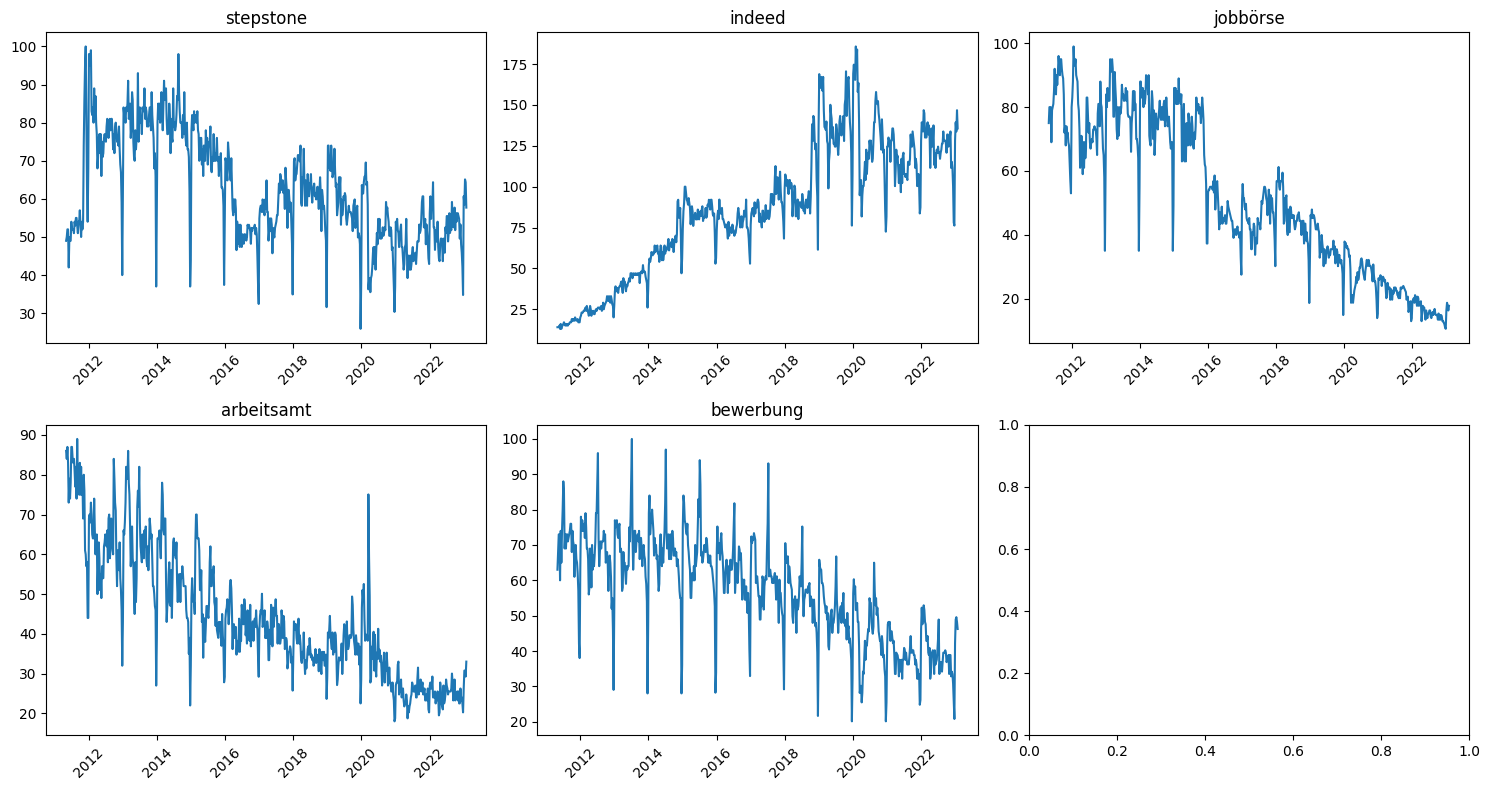

In [12]:
import matplotlib.pyplot as plt


keywords = ["stepstone", "indeed", "jobbörse", "arbeitsamt", "bewerbung"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, kw in zip(axes, keywords):
    ax.plot(df_week["Date"], df_week[kw])
    ax.set_title(kw)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## Descriptives of the biweekly data

The structure for the plotting section 
- (i) we plot the GT variables of W12 against W34 prev
- (ii) we plot each of the GT variables against unemplyoment rate
- (iii) we will take as well a look at possible cross correlations
- (iv) we plot seasonality boxplots 
- (v) we use an normalized index plot to compare google trends in the respective time frame

## (i) plotting the biweekly data against each other over time

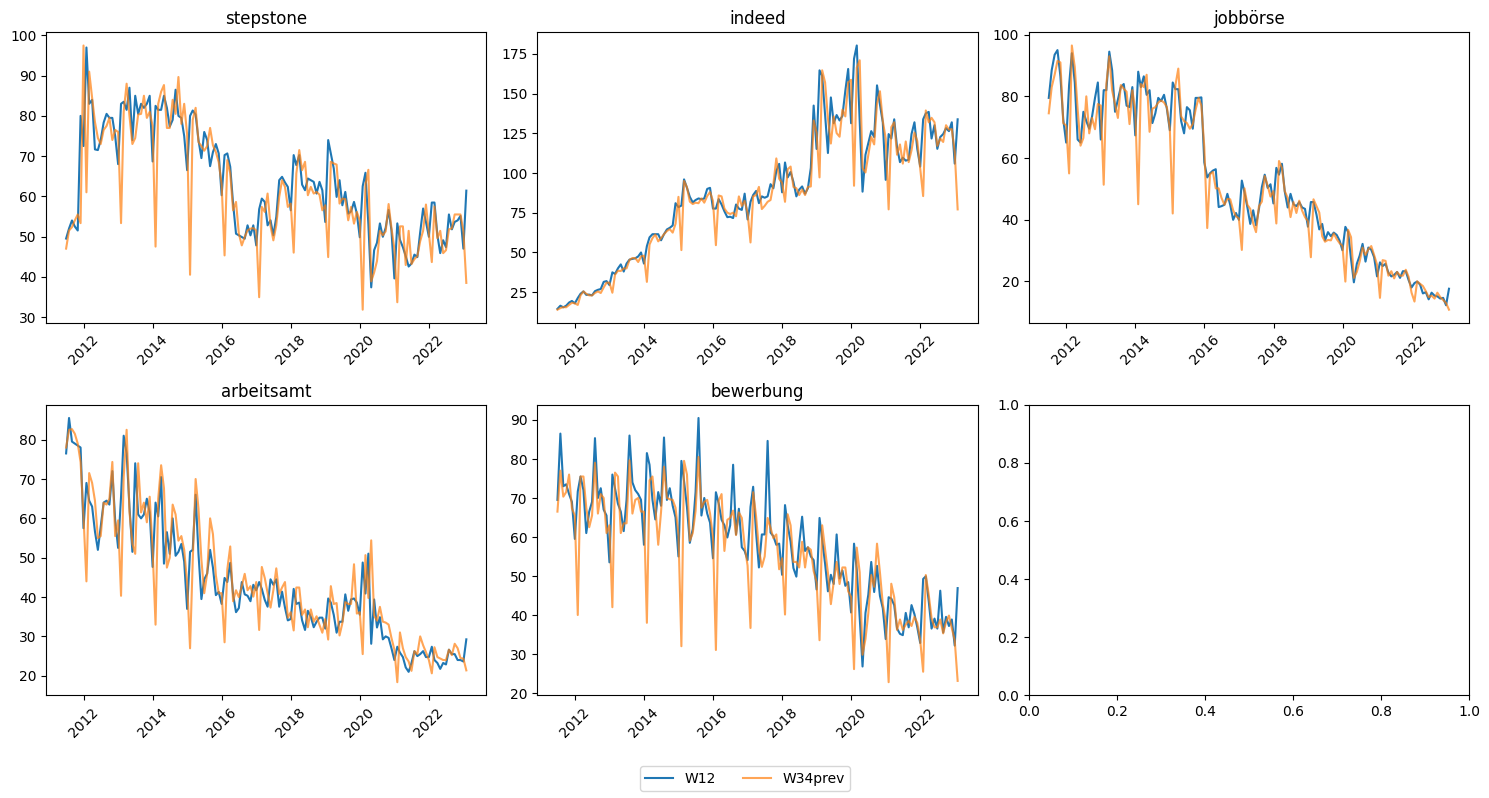

In [13]:

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, kw in zip(axes, keywords):
    ax.plot(panel.index, panel[f"{kw}_W12"], label="W12")
    ax.plot(panel.index, panel[f"{kw}_W34prev"], label="W34prev", alpha=0.7)
    ax.set_title(kw)
    ax.tick_params(axis='x', rotation=45)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

Both W12 and W34prev display highly regular and pronounced seasonal fluctuations, especially for the public–sector related terms arbeitsamt, jobbörse and bewerbung. These indicators follow a clear intra-year cycle with strong peaks at the turn of the year and troughs during summer months.
Especially W34prev tends to exhibit sharper seasonal spikes than the corresponding W12. This pattern is particularly visible for bewerbung and arbeitsamt, or also the first years of jobbörse.
We could maybe say the W34prev component captures search behaviour that takes place before the measurement of month M's unemployment and is unaffected by the publication of the unemployment M-1, whereas the W12 component partly reflects reactions to official unemployment announcements at the end of the previous month. As a result, W34prev appears to retain a “cleaner” seasonal signal.
For indeed, jobbörse, arbeitsamt and bewerbubg the long-run trend component is clear.
Searches for jobbörse and arbeitsamt exhibit a persistent downward trend over 2011–2023, consistent with declining usage of the public employment service's online channels.
On the other hand indeed shows a strong upward trajectories during the 2010s, reflecting the structural an increase when it comes toGerman job search over the years .
The series for bewerbung shows a gradual, monotonic decline, consistent with the reduced use of generic application-related searches due to templates, automated systems, and platform-driven application processes.
Interesting is that arbeitsamt indeed and stepstone feature episodic bursts, most notably around 2020–2021 during the COVID-19 shock. These spikes suggest heightened job-search uncertainty during periods of macroeconomic stress and motivate the use of models capable of capturing such nonlinearities.
Bewerbung and jobbörse on the other hand are not that affected and the trend remains to clear to see maybe also a consequence of the decline in suage or not the interest.
Overall the biweekly aggregation looks internally coherent and that both series track similar underlying behavioural patterns, with W34prev often showing a clearer seasonal structure.


## (ii) Plotting the GT against unemployment iver time 
- first for W34 prev

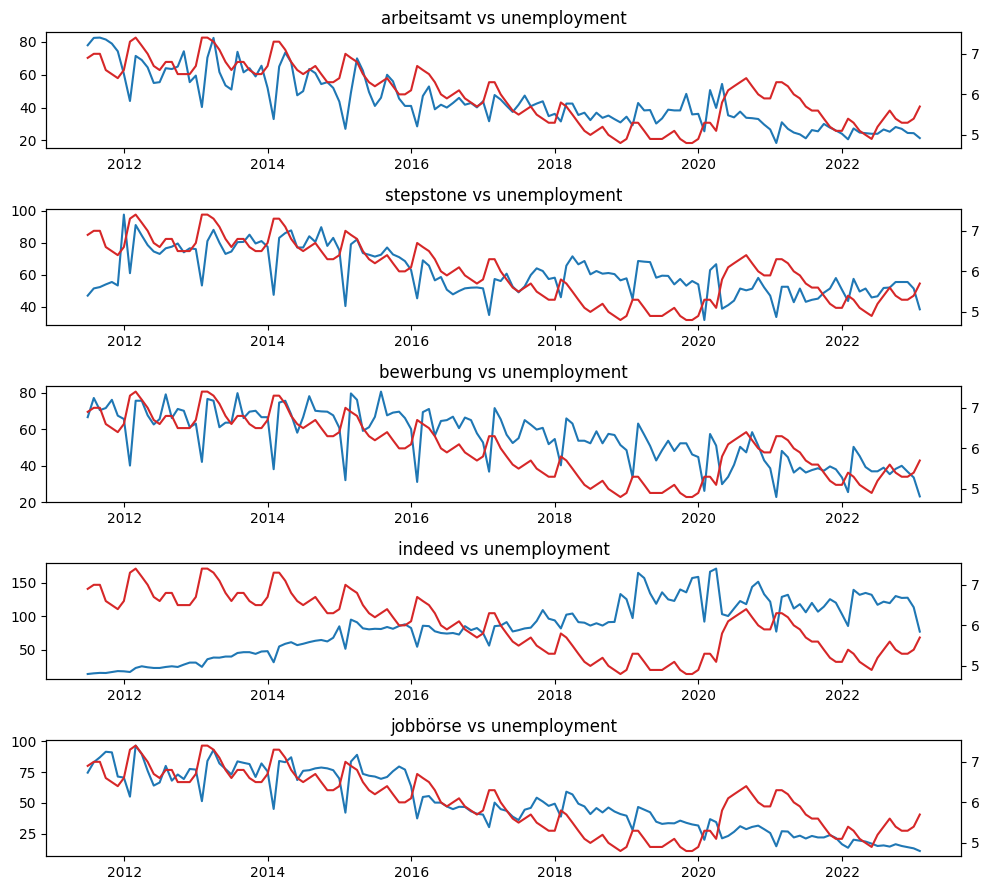

In [14]:
fig, axes = plt.subplots(5, 1, figsize=(10, 9))

for ax, kw in zip(axes, ["arbeitsamt", "stepstone", "bewerbung","indeed","jobbörse"]):
    ax2 = ax.twinx()
    ax.plot(panel.index, panel[f"{kw}_W34prev"], label=f"{kw} (W34prev)", color="tab:blue")
    ax2.plot(panel.index, panel["Unemp"], label="Unemployment", color="tab:red")
    ax.set_title(f"{kw} vs unemployment")

plt.tight_layout()
plt.show()


- for W12

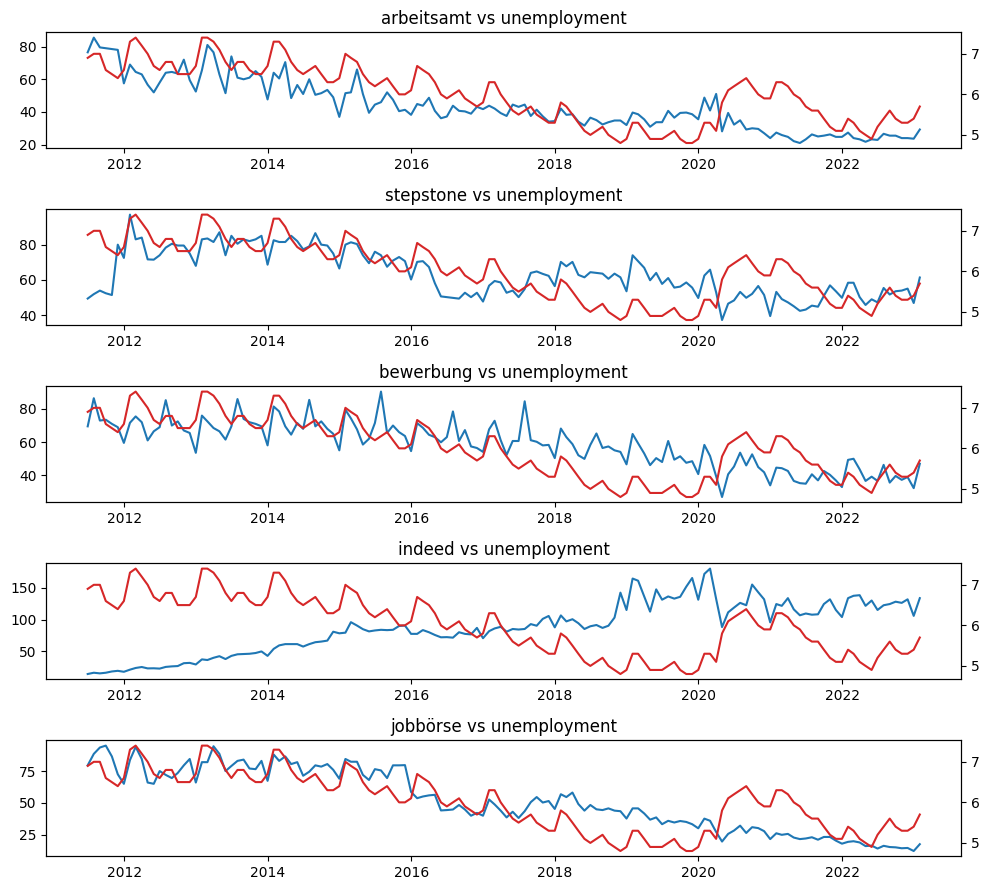

In [15]:
fig, axes = plt.subplots(5, 1, figsize=(10, 9))

for ax, kw in zip(axes, ["arbeitsamt", "stepstone", "bewerbung","indeed","jobbörse"]):
    ax2 = ax.twinx()
    ax.plot(panel.index, panel[f"{kw}_W12"], label=f"{kw} (W12)", color="tab:blue")
    ax2.plot(panel.index, panel["Unemp"], label="Unemployment", color="tab:red")
    ax.set_title(f"{kw} vs unemployment")

plt.tight_layout()
plt.show()


## (iii) Cross correlation functions

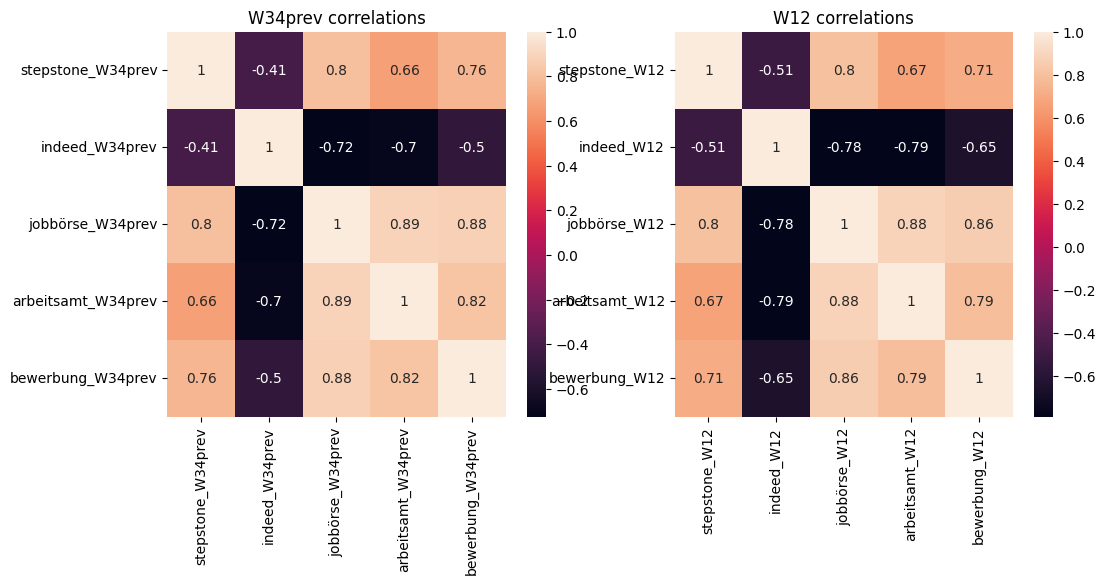

In [16]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.heatmap(panel[[c for c in panel.columns if "W34prev" in c]].corr(), ax=axes[0], annot=True)
sns.heatmap(panel[[c for c in panel.columns if "W12" in c]].corr(), ax=axes[1], annot=True)
axes[0].set_title("W34prev correlations")
axes[1].set_title("W12 correlations")
plt.show()


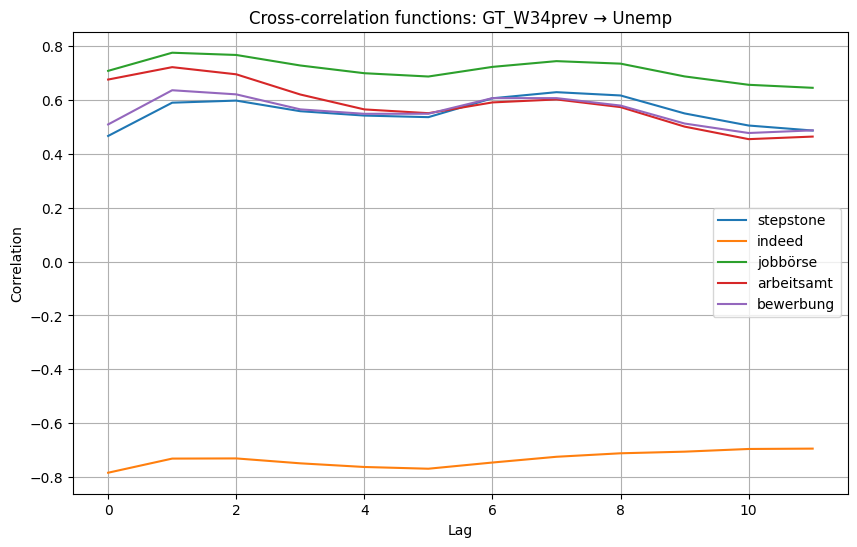

In [17]:
from statsmodels.tsa.stattools import ccf

lags = 12

plt.figure(figsize=(10, 6))

for kw in keywords:
    x = panel[f"{kw}_W34prev"]
    y = panel["Unemp"]
    corr = ccf(x, y)[:lags]
    plt.plot(range(lags), corr, label=f"{kw}")

plt.title("Cross-correlation functions: GT_W34prev → Unemp")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.legend()
plt.grid(True)
plt.show()

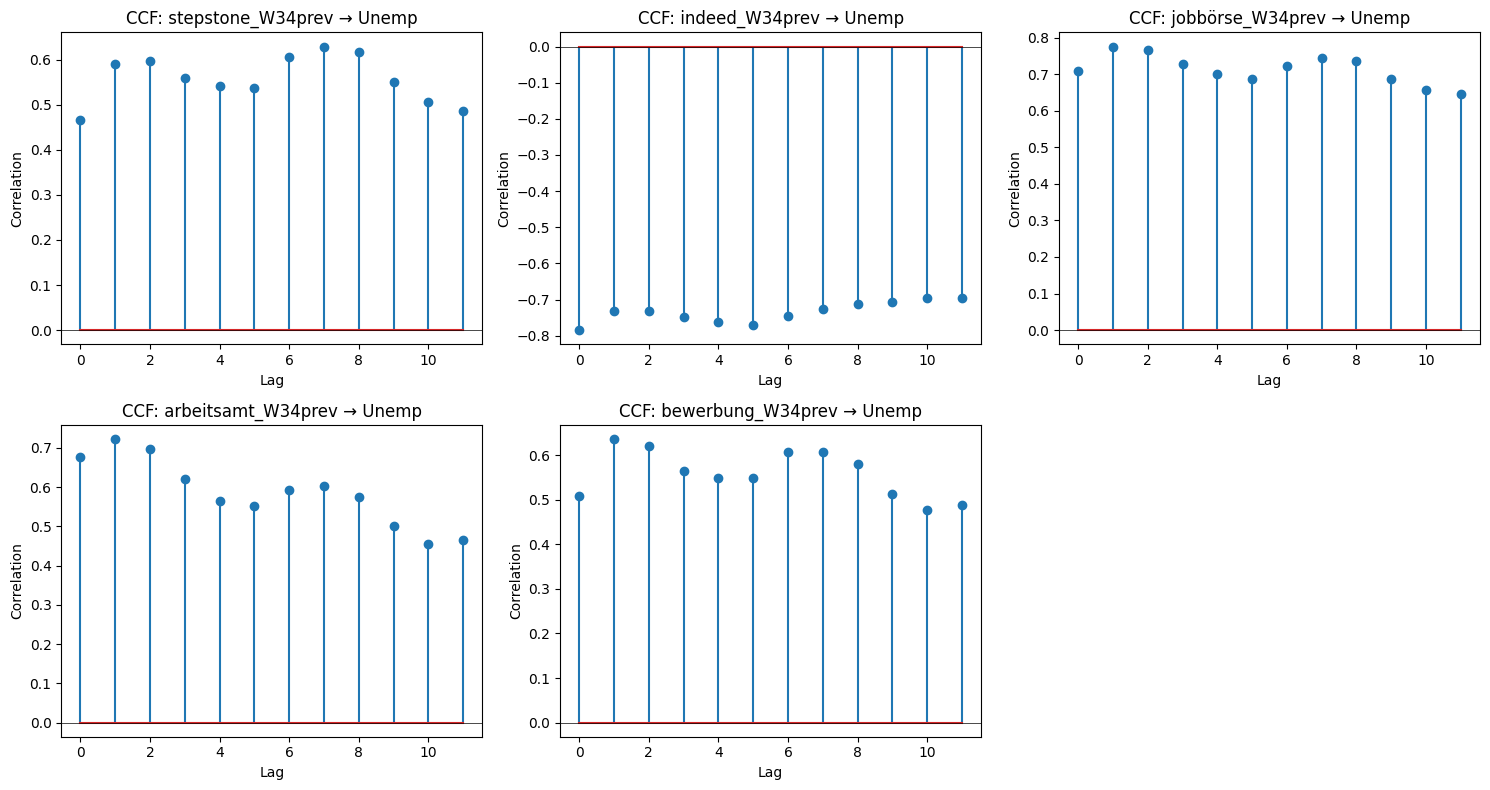

In [18]:
from statsmodels.tsa.stattools import ccf


lags = 12
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, kw in zip(axes, keywords):
    x = panel[f"{kw}_W34prev"].astype(float).values
    y = panel["Unemp"].astype(float).values

    corr = ccf(x, y)[:lags]

    ax.stem(range(lags), corr)    # <-- FIXED
    ax.axhline(0, color="black", linewidth=0.5)

    ax.set_title(f"CCF: {kw}_W34prev → Unemp")
    ax.set_xlabel("Lag")
    ax.set_ylabel("Correlation")

# Hide unused subplot
for ax in axes[len(keywords):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## (iv) Seasonality boxplots

- for W34 prev

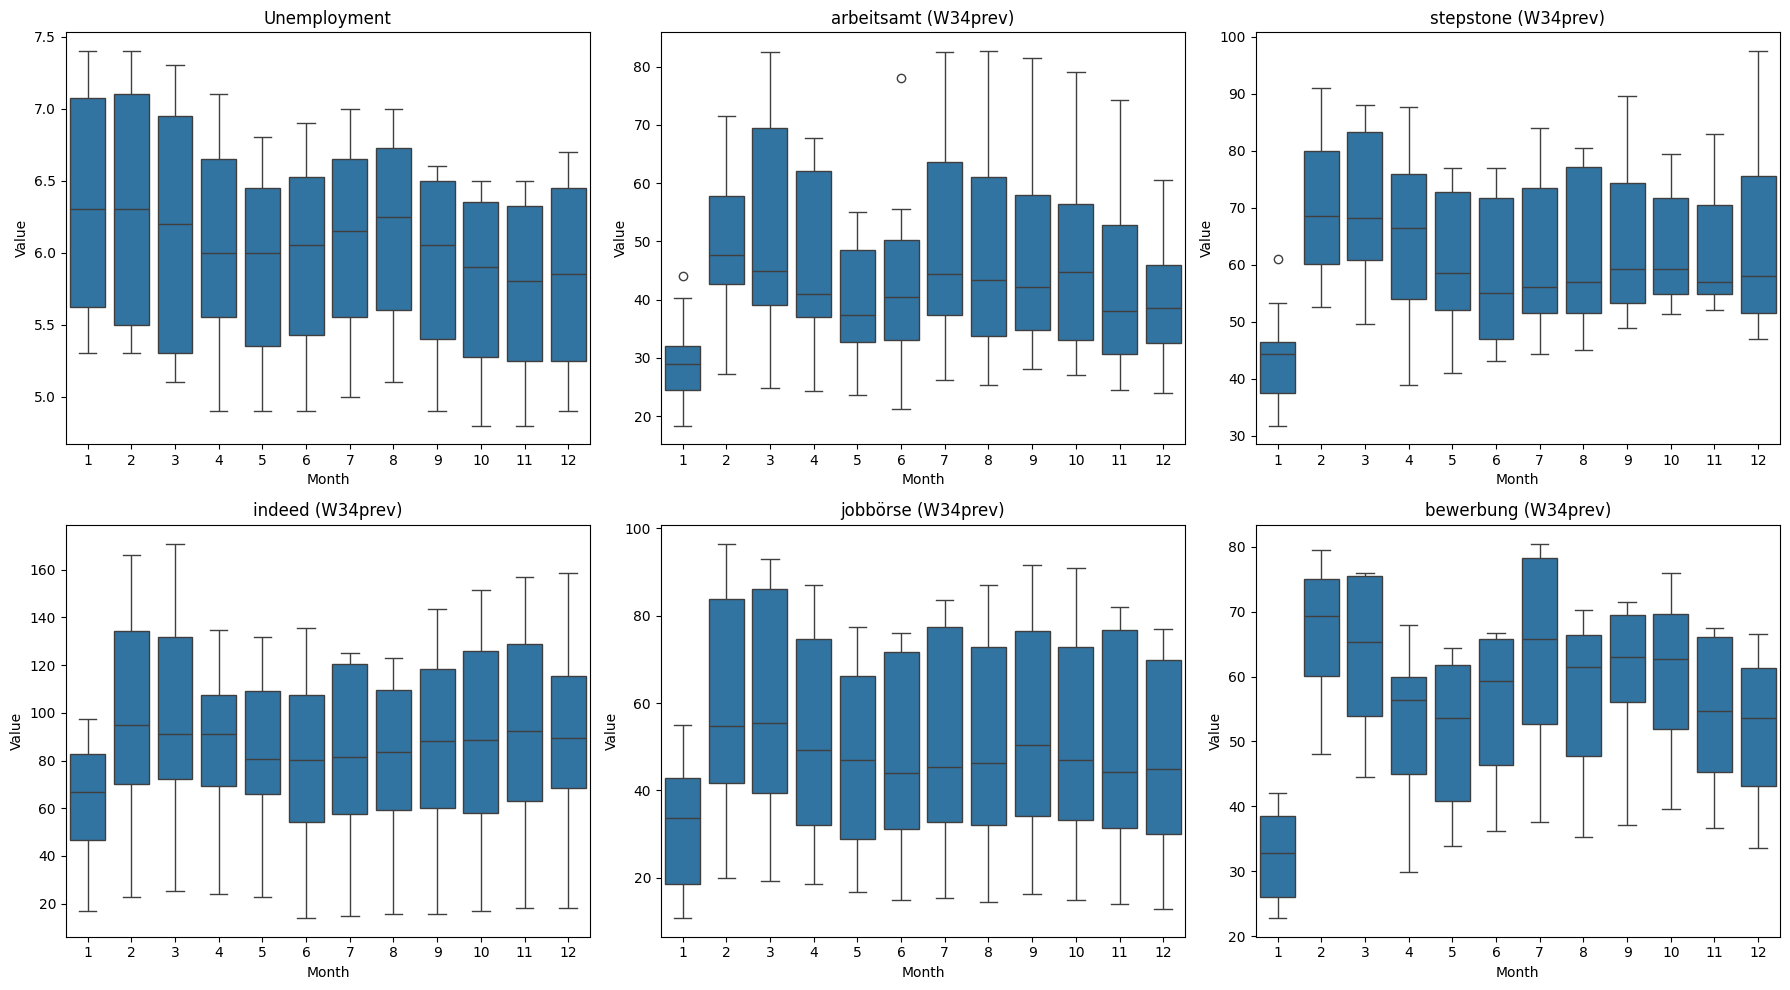

In [19]:
import seaborn as sns


# Ensure month column exists
panel["month"] = panel.index.month

# Order of variables shown in the grid
vars_to_plot = [
    "Unemp",
    "arbeitsamt_W34prev",
    "stepstone_W34prev",
    "indeed_W34prev",
    "jobbörse_W34prev",
    "bewerbung_W34prev"
]

titles = [
    "Unemployment",
    "arbeitsamt (W34prev)",
    "stepstone (W34prev)",
    "indeed (W34prev)",
    "jobbörse (W34prev)",
    "bewerbung (W34prev)"
]

# Create 2×3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, var, title in zip(axes, vars_to_plot, titles):
    sns.boxplot(x="month", y=var, data=panel, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()


- for W12

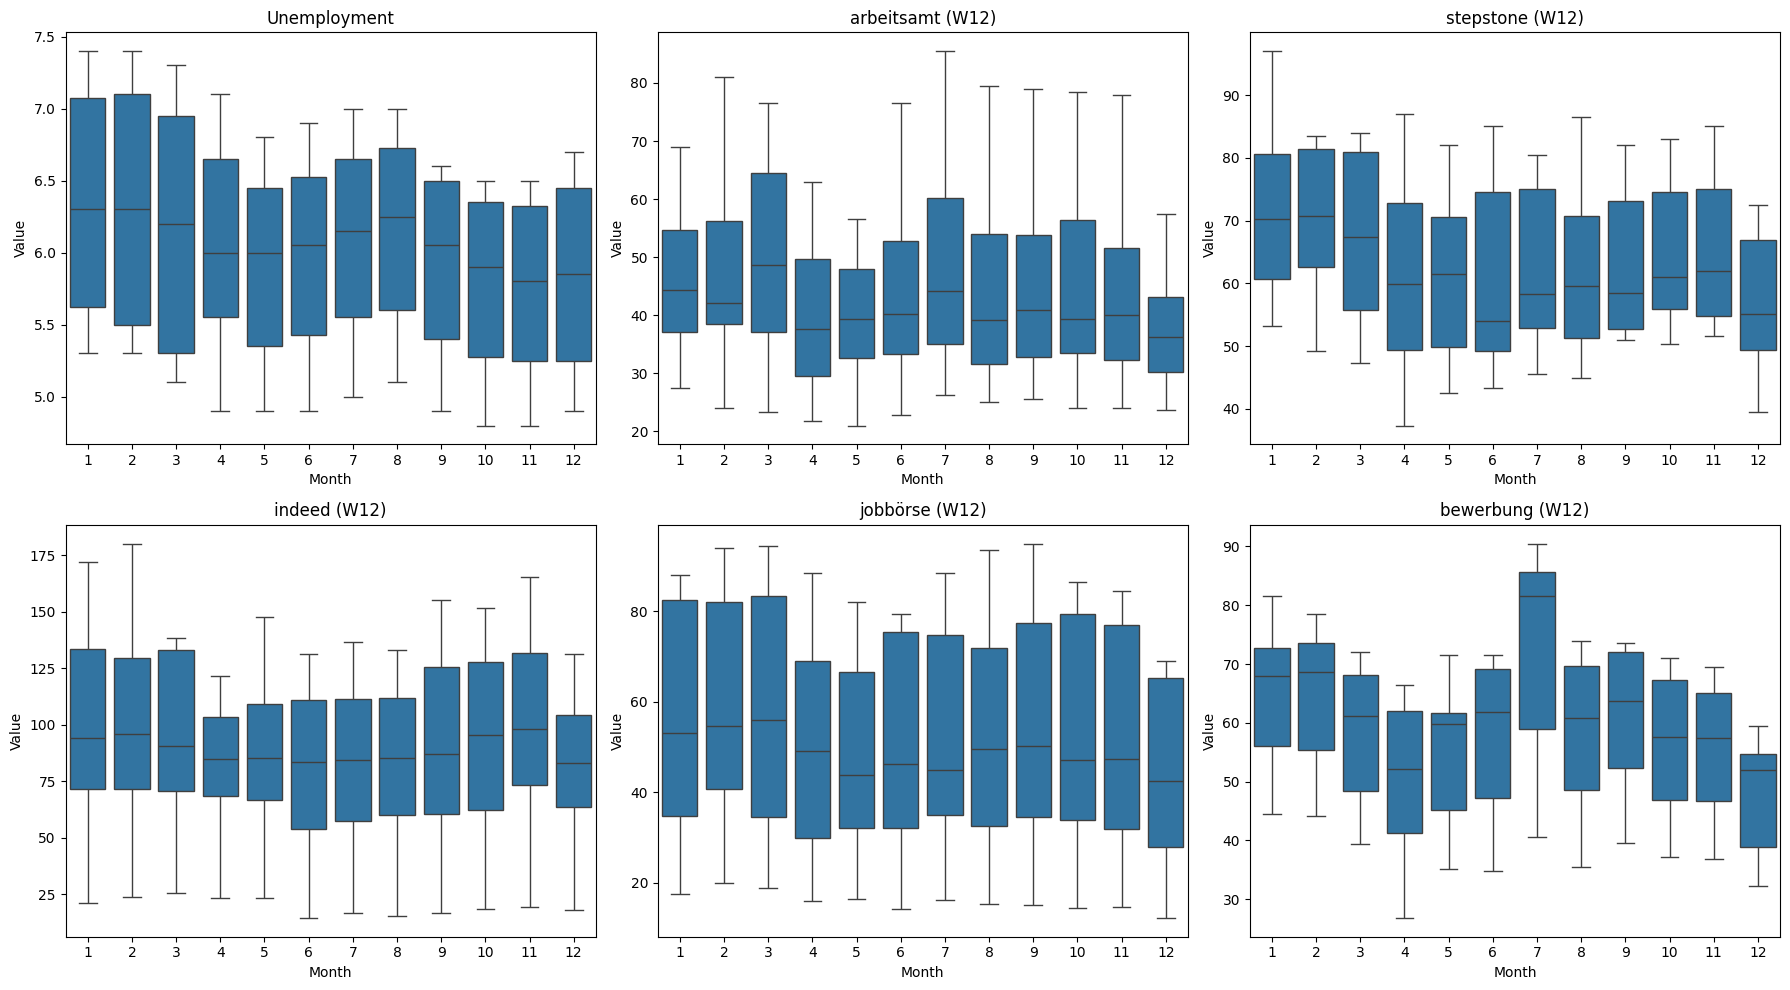

In [20]:




# Order of variables shown in the grid
vars_to_plot = [
    "Unemp",
    "arbeitsamt_W12",
    "stepstone_W12",
    "indeed_W12",
    "jobbörse_W12",
    "bewerbung_W12"
]

titles = [
    "Unemployment",
    "arbeitsamt (W12)",
    "stepstone (W12)",
    "indeed (W12)",
    "jobbörse (W12)",
    "bewerbung (W12)"
]

# Create 2×3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, var, title in zip(axes, vars_to_plot, titles):
    sns.boxplot(x="month", y=var, data=panel, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()


## (v) Normalized index plot

- for W12

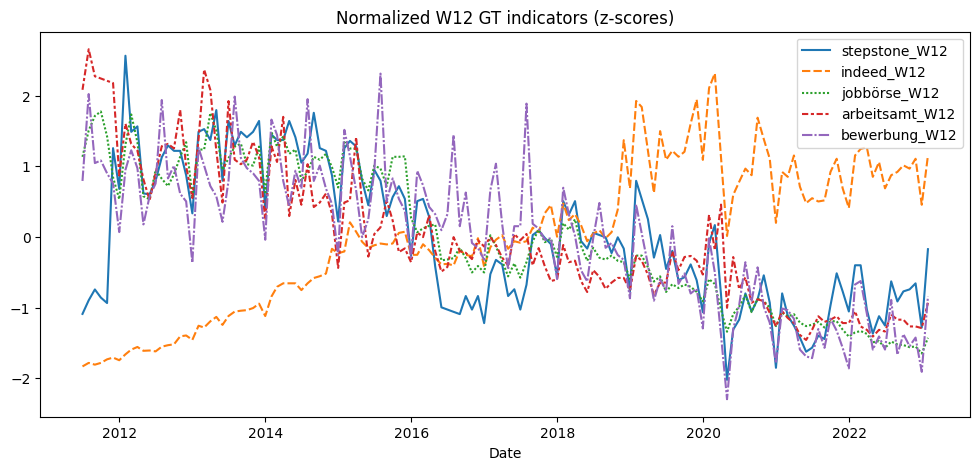

In [21]:

gt_cols = [col for col in panel.columns if "W12" in col]
gt_norm = (panel[gt_cols] - panel[gt_cols].mean()) / panel[gt_cols].std()

plt.figure(figsize=(12,5))
sns.lineplot(data=gt_norm)
plt.title("Normalized W12 GT indicators (z-scores)")
plt.show()


- for W34 prev

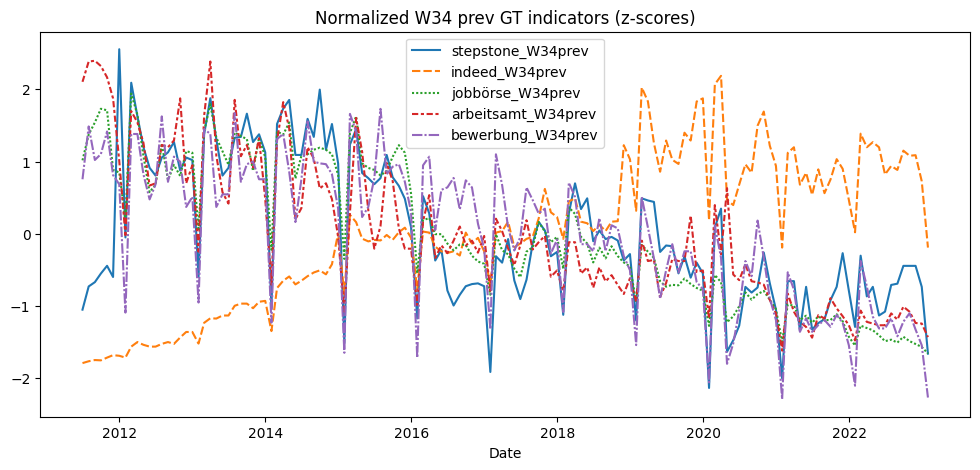

In [22]:

gt_cols = [col for col in panel.columns if "W34prev" in col]
gt_norm = (panel[gt_cols] - panel[gt_cols].mean()) / panel[gt_cols].std()

plt.figure(figsize=(12,5))
sns.lineplot(data=gt_norm)
plt.title("Normalized W34 prev GT indicators (z-scores)")
plt.show()

# Stationarity tests for the variables

- the biweekly variables

In [23]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller


MIN_LEN = 20
MAXLAG = 13           # upper bound for monthly data 
OUT_CSV = "adf_panel_simple.csv"

def run_adf(series: pd.Series,
            name: str,
            maxlag: int = MAXLAG,
            min_len: int = MIN_LEN) -> pd.DataFrame:

    series = pd.to_numeric(series, errors="coerce")
    series = series.dropna()

    results = []
    cols = [
        "series", "transform", "reg",
        "adf_stat", "pvalue",
        "used_lag", "nobs_eff", "nobs_raw",
        "crit_1pct", "crit_5pct", "crit_10pct",
        "reject_1pct", "reject_5pct", "reject_10pct"
    ]

    def run_one(x, transform_label):
        x = pd.Series(x).dropna()
        nraw = x.shape[0]

        if nraw < min_len:
            for reg in ("n", "c", "ct"):
                results.append((name, transform_label, reg,
                                np.nan, np.nan,
                                np.nan, np.nan, nraw,
                                np.nan, np.nan, np.nan,
                                False, False, False))
            return

        for reg in ("n", "c", "ct"):
            stat, p, usedlag, nobs, crit, icbest = adfuller(
                x,
                regression=reg,          
                maxlag=maxlag,
                autolag="AIC"             # lag chosen by AIC
            )
            c1, c5, c10 = crit["1%"], crit["5%"], crit["10%"]

            # reject if statistic is more negative than critical value
            r1 = stat < c1
            r5 = stat < c5
            r10 = stat < c10

            results.append((name, transform_label, reg,
                            stat, p,
                            usedlag, nobs, nraw,
                            c1, c5, c10,
                            r1, r5, r10))

    # Level
    run_one(series, "level")
    # First difference
    run_one(series.diff(), "diff1")

    return pd.DataFrame(results, columns=cols)




all_res = []

for col in panel.columns:
    res = run_adf(panel[col], name=col)
    all_res.append(res)

    print("\n" + "="*70)
    print(f"ADF results for {col}")
    with pd.option_context("display.float_format", "{:,.4f}".format):
        print(res.to_string(index=False))

adf_summary = pd.concat(all_res, ignore_index=True)
adf_summary.to_csv(OUT_CSV, index=False)
print(f"\nSaved ADF summary to {OUT_CSV}")



ADF results for stepstone_W12
       series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
stepstone_W12     level   n   -0.9831  0.2949        12       127       140    -2.5836    -1.9433     -1.6149        False        False         False
stepstone_W12     level   c   -1.6889  0.4368        13       126       140    -3.4833    -2.8848     -2.5792        False        False         False
stepstone_W12     level  ct   -2.5111  0.3224        13       126       140    -4.0325    -3.4459     -3.1478        False        False         False
stepstone_W12     diff1   n   -3.2242  0.0013        11       127       139    -2.5836    -1.9433     -1.6149         True         True          True
stepstone_W12     diff1   c   -3.2986  0.0149        11       127       139    -3.4829    -2.8846     -2.5791        False         True          True
stepstone_W12     diff1  ct   -3.2441  0.0760        11       127    

- the standard weekly variables

In [24]:
# removing the week index for the dickey fuller test as it is a constant 
df_week.drop(columns="Date", axis = 1, inplace=True)
# defining the upper bound for the weekly data
MIN_LEN = 20
MAXLAG = 52          

all_res = []

for col in df_week.columns:
    res = run_adf(df_week[col], name=col)
    all_res.append(res)

    print("\n" + "="*70)
    print(f"ADF results for {col}")
    with pd.option_context("display.float_format", "{:,.4f}".format):
        print(res.to_string(index=False))

adf_summary = pd.concat(all_res, ignore_index=True)



ADF results for stepstone
   series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
stepstone     level   n   -0.3352  0.5624        13       600       614    -2.5695    -1.9415     -1.6164        False        False         False
stepstone     level   c   -2.3279  0.1631        12       601       614    -3.4413    -2.8664     -2.5693        False        False         False
stepstone     level  ct   -4.9716  0.0002         8       605       614    -3.9738    -3.4178     -3.1313         True         True          True
stepstone     diff1   n  -10.1611  0.0000        12       600       613    -2.5695    -1.9415     -1.6164         True         True          True
stepstone     diff1   c  -10.1526  0.0000        12       600       613    -3.4413    -2.8664     -2.5693         True         True          True
stepstone     diff1  ct  -10.1639  0.0000        12       600       613    -3.9739    -3.4178    

# Checking the biweekly variables on cointegration

In [25]:

import statsmodels.api as sm



# Adjust this to your actual DataFrame name
df = panel.copy()  # or panel.copy()

Y_COL = "Unemp"

# List all biweekly GT variables you want to test
GT_COLS = [
    "stepstone_W12",
    "indeed_W12",
    "jobbörse_W12",
    "arbeitsamt_W12",
    "bewerbung_W12",
    "stepstone_W34prev",
    "indeed_W34prev",
    "jobbörse_W34prev",
    "arbeitsamt_W34prev",
    "bewerbung_W34prev",
]

# --------------------------------------------------
# Helper: build monthly dummies
# --------------------------------------------------

def add_month_dummies(df, drop_first=True, prefix="m"):
    """Add 11 monthly dummies (for 12 months) to a DataFrame based on its DatetimeIndex."""
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("Index must be a DatetimeIndex to create month dummies.")
    month = df.index.month
    dummies = pd.get_dummies(month, prefix=prefix, dtype=float)
    if drop_first:
        dummies = dummies.iloc[:, 1:]
    return df.join(dummies)

# --------------------------------------------------
# Engle–Granger test for one GT variable
# --------------------------------------------------

from statsmodels.tsa.stattools import coint

def engle_granger_simple(df, y_col, x_col):
    data = df[[y_col, x_col]].dropna()
    y = data[y_col]
    x = data[x_col]

    stat, pvalue, crit = coint(y, x, trend="c")  # Case 2

    return {
        "series": x_col,
        "eg_stat": stat,
        "pvalue": pvalue,
        "crit_1pct": crit[0],
        "crit_5pct": crit[1],
        "crit_10pct": crit[2],
        "reject_5pct": stat < crit[1],
    }


In [26]:
eg_results = []
for col in GT_COLS:
    eg_results.append(engle_granger_simple(panel, "Unemp", col))

eg_summary = pd.DataFrame(eg_results)
print(eg_summary)


               series   eg_stat    pvalue  crit_1pct  crit_5pct  crit_10pct  \
0       stepstone_W12 -2.577911  0.245829  -3.976966  -3.380441   -3.075103   
1          indeed_W12 -2.958391  0.120430  -3.976966  -3.380441   -3.075103   
2        jobbörse_W12 -2.858216  0.147863  -3.976966  -3.380441   -3.075103   
3      arbeitsamt_W12 -3.168235  0.075403  -3.976966  -3.380441   -3.075103   
4       bewerbung_W12 -2.377943  0.335371  -3.976966  -3.380441   -3.075103   
5   stepstone_W34prev -2.588815  0.241362  -3.976966  -3.380441   -3.075103   
6      indeed_W34prev -3.485516  0.033701  -3.976966  -3.380441   -3.075103   
7    jobbörse_W34prev -3.203768  0.069300  -3.976966  -3.380441   -3.075103   
8  arbeitsamt_W34prev -2.956172  0.120994  -3.976966  -3.380441   -3.075103   
9   bewerbung_W34prev -2.394768  0.327337  -3.976966  -3.380441   -3.075103   

   reject_5pct  
0        False  
1        False  
2        False  
3        False  
4        False  
5        False  
6         T

# Nowcasting

In [ ]:

# my packages I need
import statsmodels.api as sm

from pathlib import Path
from typing import Dict, List, Optional, Tuple


In [40]:
# --- mandatory weekly_panel fix ---
assert "Date" in df_week.columns, "df_week must still contain a Date column at this step."

df_week = df_week.copy()
df_week["Date"] = pd.to_datetime(df_week["Date"], errors="coerce").dt.tz_localize(None)
df_week = df_week.sort_values("Date")

weekly_cols = ["stepstone", "indeed", "jobbörse", "arbeitsamt", "bewerbung"]
weekly_panel = df_week.set_index("Date")[weekly_cols].sort_index()

# sanity checks
print(weekly_panel.index.min(), weekly_panel.index.max())
print(weekly_panel.index[:5])


2011-05-01 00:00:00 2023-01-29 00:00:00
DatetimeIndex(['2011-05-01', '2011-05-08', '2011-05-15', '2011-05-22',
               '2011-05-29'],
              dtype='datetime64[ns]', name='Date', freq=None)


In [41]:
weekly_panel

,stepstone,indeed,jobbörse,arbeitsamt,bewerbung
Date,,,,,
2011-05-01,49.000000,14.000000,75.000000,86.000000,63.000000
2011-05-08,50.000000,14.000000,80.000000,84.000000,68.000000
2011-05-15,52.000000,14.000000,80.000000,87.000000,73.000000
2011-05-22,52.000000,15.000000,80.000000,83.000000,73.000000
2011-05-29,42.000000,13.000000,69.000000,73.000000,60.000000
...,...,...,...,...,...
2023-01-01,60.670120,128.215336,16.313392,26.270023,42.207649
2023-01-08,58.450482,139.364496,18.712420,30.773455,48.907276
2023-01-15,65.109398,133.789916,17.752809,30.773455,49.577239


In [29]:

panel = panel.copy()
panel.index = pd.to_datetime(panel.index, errors="coerce").tz_localize(None)
panel = panel.sort_index()

assert "Unemp" in panel.columns
assert panel.index.is_month_end.all()
panel.head()


,stepstone_W12,indeed_W12,jobbörse_W12,arbeitsamt_W12,bewerbung_W12,stepstone_W34prev,indeed_W34prev,jobbörse_W34prev,arbeitsamt_W34prev,bewerbung_W34prev,Unemp,month
Date,,,,,,,,,,,,
2011-06-30,49.5,14.5,79.5,76.5,69.5,47.000000,14.000000,74.5,78.000000,66.500000,6.9,6
2011-07-31,52.0,16.5,88.5,85.5,86.5,51.500000,15.000000,83.0,82.500000,77.000000,7.0,7
2011-08-31,54.0,15.5,93.5,79.5,73.0,52.333333,15.666667,87.0,82.666667,70.333333,7.0,8
2011-09-30,52.5,16.5,95.0,79.0,73.5,54.000000,15.500000,91.5,81.500000,71.500000,6.6,9
2011-10-31,51.5,18.5,86.5,78.5,71.0,55.500000,17.000000,91.0,79.000000,76.000000,6.5,10


## configuration code

In [42]:
from dataclasses import dataclass
from typing import Tuple

@dataclass
class CFG:
    # Sample endpoints
    start_week: str = "2011-05-01"
    end_week: str   = "2023-01-29"
    start_month: str = "2011-06-30"
    end_month: str   = "2023-01-31"

    # Evaluation timeframe
    eval_start: str = "2019-01-31"
    min_train: int = 60

    # Deterministics / transformations
    seasonal_dummies: bool = True
    target_transform: str = "diff"   # keep diff for nowcasting baseline

    # Lag selection controls
    ar_max_p: int = 6
    arx_max_p: int = 4
    arx_max_q: int = 2
    ic: str = "BIC"                  # AIC or BIC

    # MIDAS controls
    midas_K_candidates: Tuple[int, ...] = (4, 6, 8)
    midas_include_ar: bool = True
    midas_diff_weekly: bool = True

cfg = CFG()


In [43]:
def build_umidas_design(
    weekly_panel: pd.DataFrame,
    unemp_monthly: pd.Series,
    gt_col: str,
    K: int = 8,
    target_transform: str = "diff",   # "diff" or "level"
    weekly_transform: str = "diff",   # "diff" or "level"
    seasonal_dummies: bool = True,
    drop_first_dummy: bool = True
) -> pd.DataFrame:


    # --- Ensure proper indices
    wk = weekly_panel[[gt_col]].copy().sort_index()
    wk.index = pd.to_datetime(wk.index).tz_localize(None)

    U = unemp_monthly.copy().sort_index()
    U.index = pd.to_datetime(U.index).tz_localize(None)

    # --- Transform target and weekly regressor
    y = U.diff() if target_transform == "diff" else U
    x = wk[gt_col].diff() if weekly_transform == "diff" else wk[gt_col]

    # --- Build rows
    rows = []
    idx = []
    for t in y.index:
        if pd.isna(y.loc[t]):
            continue
        x_up_to_t = x.loc[x.index <= t].dropna()
        if len(x_up_to_t) < K:
            continue

        lastK = x_up_to_t.iloc[-K:]  # oldest..newest
        # define wlag0 = most recent week, wlag1 = one week older, ...
        vals = lastK.iloc[::-1].values

        rows.append([y.loc[t]] + list(vals))
        idx.append(t)

    cols = ["y"] + [f"wlag{k}" for k in range(K)]
    design = pd.DataFrame(rows, index=pd.to_datetime(idx), columns=cols).sort_index()

    # --- Optional seasonal dummies on monthly index
    if seasonal_dummies:
        d = pd.get_dummies(design.index.month, prefix="m", drop_first=drop_first_dummy).astype(float)
        d.index = design.index
        design = pd.concat([design, d], axis=1)

    return design


In [46]:
EVAL_START = cfg.eval_start
MIN_TRAIN  = cfg.min_train

def compute_metrics(pred: pd.Series, act: pd.Series) -> dict:
    pred, act = pred.align(act, join="inner")
    err = pred - act
    return {
        "RMSE": float(np.sqrt(np.mean(err**2))),
        "MAE": float(np.mean(np.abs(err))),
        "n": int(err.shape[0]),
    }

def month_dummies(index: pd.DatetimeIndex, drop_first=True) -> pd.DataFrame:
    d = pd.get_dummies(index.month, prefix="m", drop_first=drop_first).astype(float)
    d.index = index
    return d


In [ ]:
from typing import Optional, Tuple

def ic_value(res, ic: str) -> float:
    ic = ic.upper()
    if ic == "AIC":
        return float(res.aic)
    elif ic == "BIC":
        return float(res.bic)
    else:
        raise ValueError("ic must be 'AIC' or 'BIC'")

def select_ar_p(y: pd.Series, max_p: int, ic: str, dummies: Optional[pd.DataFrame]) -> int:
    best = (np.inf, 1)
    for p in range(1, max_p + 1):
        df = pd.concat([y] + [y.shift(j) for j in range(1, p + 1)], axis=1)
        df.columns = ["y"] + [f"lag{j}" for j in range(1, p + 1)]
        if dummies is not None:
            df = df.join(dummies)
        df = df.dropna()
        if df.empty:
            continue
        res = sm.OLS(df["y"], sm.add_constant(df.drop(columns=["y"]), has_constant="add")).fit()
        val = ic_value(res, ic)
        if val < best[0]:
            best = (val, p)
    return best[1]

def select_arx_pq(y: pd.Series, x: pd.Series, max_p: int, max_q: int, ic: str, dummies: Optional[pd.DataFrame]) -> Tuple[int, int]:
    best = (np.inf, 1, 0)
    base = pd.concat([y.rename("y"), x.rename("x")], axis=1)

    for p in range(1, max_p + 1):
        for q in range(0, max_q + 1):
            df = base.copy()
            for j in range(1, p + 1):
                df[f"y_lag{j}"] = df["y"].shift(j)
            for k in range(0, q + 1):
                df[f"x_lag{k}"] = df["x"].shift(k)
            if dummies is not None:
                df = df.join(dummies)
            df = df.dropna()
            if df.empty:
                continue
            res = sm.OLS(df["y"], sm.add_constant(df.drop(columns=["y"]), has_constant="add")).fit()
            val = ic_value(res, ic)
            if val < best[0]:
                best = (val, p, q)
    return best[1], best[2]



In [47]:
# result container
@dataclass
class Result:
    name: str
    pred: pd.Series
    act: pd.Series
    err: pd.Series
    metrics: Dict[str, float]
    meta: Dict[str, object]


## Constructing the nowcast models 

In [48]:
def nowcast_ar_diff(panel: pd.DataFrame, start_eval: str,
                    p: int = 2, min_train: int = 60,
                    seasonal_dummies: bool = True):
    df = panel[["Unemp"]].copy()
    U = pd.to_numeric(df["Unemp"], errors="coerce")
    dU = U.diff()

    for j in range(1, p + 1):
        df[f"dU_lag{j}"] = dU.shift(j)

    dummies = month_dummies(df.index) if seasonal_dummies else None
    reg_cols = [f"dU_lag{j}" for j in range(1, p + 1)]

    preds, acts, idx = [], [], []

    for t in df.loc[start_eval:].index:
        est = df.loc[df.index < t].copy()
        est["dU"] = dU.loc[est.index]
        est = est.dropna(subset=["dU"] + reg_cols)

        if len(est) < min_train:
            continue

        X = est[reg_cols]
        if dummies is not None:
            X = pd.concat([X, dummies.loc[X.index]], axis=1)
        X = sm.add_constant(X, has_constant="add")

        res = sm.OLS(est["dU"], X).fit()

        x_t = df.loc[[t], reg_cols]
        if dummies is not None:
            x_t = pd.concat([x_t, dummies.loc[[t]]], axis=1)
        x_t = sm.add_constant(x_t, has_constant="add")

        dU_hat = float(res.predict(x_t))
        U_last = U.loc[U.index < t].iloc[-1]      # last observed before t
        U_hat = U_last + dU_hat

        preds.append(U_hat)
        acts.append(U.loc[t])
        idx.append(t)

    pred = pd.Series(preds, index=idx, name="AR_pred")
    act  = pd.Series(acts,  index=idx, name="Unemp")
    return pred, act


def nowcast_arx_diff(panel: pd.DataFrame, xcol: str, start_eval: str,
                     p: int = 2, q: int = 0,
                     min_train: int = 60,
                     seasonal_dummies: bool = True):

    df = panel[["Unemp", xcol]].copy()
    U = pd.to_numeric(df["Unemp"], errors="coerce")
    Xraw = pd.to_numeric(df[xcol], errors="coerce")

    dU = U.diff()
    dX = Xraw.diff()

    for j in range(1, p + 1):
        df[f"dU_lag{j}"] = dU.shift(j)

    df["dX_lag0"] = dX
    for k in range(1, q + 1):
        df[f"dX_lag{k}"] = dX.shift(k)

    dummies = month_dummies(df.index) if seasonal_dummies else None
    reg_cols = [f"dU_lag{j}" for j in range(1, p + 1)] + ["dX_lag0"] + [f"dX_lag{k}" for k in range(1, q + 1)]

    preds, acts, idx = [], [], []

    for t in df.loc[start_eval:].index:
        est = df.loc[df.index < t].copy()
        est["dU"] = dU.loc[est.index]
        est = est.dropna(subset=["dU"] + reg_cols)

        if len(est) < min_train:
            continue

        X = est[reg_cols]
        if dummies is not None:
            X = pd.concat([X, dummies.loc[X.index]], axis=1)
        X = sm.add_constant(X, has_constant="add")

        res = sm.OLS(est["dU"], X).fit()

        x_t = df.loc[[t], reg_cols]
        if dummies is not None:
            x_t = pd.concat([x_t, dummies.loc[[t]]], axis=1)
        x_t = sm.add_constant(x_t, has_constant="add")

        dU_hat = float(res.predict(x_t))
        U_last = U.loc[U.index < t].iloc[-1]
        U_hat = U_last + dU_hat

        preds.append(U_hat)
        acts.append(U.loc[t])
        idx.append(t)

    pred = pd.Series(preds, index=idx, name=f"ARX_pred_{xcol}")
    act  = pd.Series(acts,  index=idx, name="Unemp")
    return pred, act


## U Midas nowcasting function

In [49]:
def nowcast_umidas(
    weekly_panel: pd.DataFrame,
    unemp_monthly: pd.Series,
    gt_col: str,
    start_eval: str,
    K: int = 8,
    include_ar1: bool = True,
    target_transform: str = "diff",
    weekly_transform: str = "diff",
    seasonal_dummies: bool = True,
    min_train: int = 60
):
    design = build_umidas_design(
        weekly_panel=weekly_panel,
        unemp_monthly=unemp_monthly,
        gt_col=gt_col,
        K=K,
        target_transform=target_transform,
        weekly_transform=weekly_transform,
        seasonal_dummies=seasonal_dummies
    )

    # optional AR term in the monthly target (ΔU_{t-1})
    if include_ar1:
        design["y_lag1"] = design["y"].shift(1)

    reg_cols = [c for c in design.columns if c.startswith("wlag")]
    if include_ar1:
        reg_cols += ["y_lag1"]
    reg_cols += [c for c in design.columns if c.startswith("m_")]

    # monthly unemployment series (force month-end alignment)
    U = unemp_monthly.copy()
    U.index = pd.to_datetime(U.index).tz_localize(None)
    U.index = U.index.to_period("M").to_timestamp("M")
    U = U.sort_index()

    preds, acts, idx = [], [], []

    for t in design.loc[start_eval:].index:
        est = design.loc[design.index < t].dropna(subset=["y"] + reg_cols)
        if len(est) < min_train:
            continue

        # fit model
        X = sm.add_constant(est[reg_cols], has_constant="add")
        res = sm.OLS(est["y"], X).fit()

        # build forecast regressor row
        row_t = design.loc[[t], reg_cols]
        if row_t.isna().any(axis=1).iloc[0]:
            continue

        X_t = sm.add_constant(row_t, has_constant="add")
        yhat = float(res.predict(X_t))

        # convert back to level forecast
        if target_transform == "diff":
            U_last = U.loc[U.index < t].iloc[-1]
            U_hat = U_last + yhat
        else:
            U_hat = yhat

        preds.append(U_hat)
        acts.append(U.loc[t])
        idx.append(t)

    pred = pd.Series(preds, index=idx, name=f"MIDAS_pred_{gt_col}")
    act  = pd.Series(acts,  index=idx, name="Unemp")
    return pred, act


## All model evaluation

In [60]:
def run_horserace(panel: pd.DataFrame, weekly_panel: pd.DataFrame, cfg):

    results = []

    # ---------- 1) AR benchmark ----------
    p_ar = 2  # keep fixed unless you plug in select_ar_p
    ar_pred, ar_act = nowcast_ar_diff(
        panel=panel,
        start_eval=cfg.eval_start,
        p=p_ar,
        min_train=cfg.min_train,
        seasonal_dummies=cfg.seasonal_dummies
    )
    ar_name = f"AR(dU,p={p_ar})"
    results.append((ar_name, ar_pred, ar_act))

    # ---------- 2) ARX: all biweekly columns ----------
    # only GT columns (avoid accidental inclusion of helper cols like 'month')
    arx_cols = [c for c in panel.columns if (c.endswith("_W12") or c.endswith("_W34prev"))]

    p_arx = 2
    q_arx = 0
    for xcol in arx_cols:
        pred, act = nowcast_arx_diff(
            panel=panel,
            xcol=xcol,
            start_eval=cfg.eval_start,
            p=p_arx,
            q=q_arx,
            min_train=cfg.min_train,
            seasonal_dummies=cfg.seasonal_dummies
        )
        name = f"ARX(dU,p={p_arx}; dX,q={q_arx})[{xcol}]"
        results.append((name, pred, act))

    # ---------- 3) U-MIDAS: weekly keywords ----------
    K = 8
    weekly_keywords = ["stepstone", "indeed", "jobbörse", "arbeitsamt", "bewerbung"]
    for kw in weekly_keywords:
        pred, act = nowcast_umidas(
            weekly_panel=weekly_panel,
            unemp_monthly=panel["Unemp"],
            gt_col=kw,
            start_eval=cfg.eval_start,
            K=K,
            include_ar1=False,
            target_transform="diff",
            weekly_transform="diff",
            seasonal_dummies=cfg.seasonal_dummies,
            min_train=cfg.min_train
        )
        name = f"U-MIDAS(dU; K={K}; ar1=0; dW=1)[{kw}]"
        results.append((name, pred, act))

    # ---------- Build leaderboard + store ----------
    rows = []
    store = {}

    for name, pred, act in results:
        pred, act = pred.align(act, join="inner")
        err = pred - act

        m = compute_metrics(pred, act)
        rows.append({"model": name, **m})
        store[name] = {"pred": pred, "act": act, "err": err}

    leaderboard = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
    return leaderboard, store


# Run once
leaderboard, store = run_horserace(panel, weekly_panel, cfg)
leaderboard.head(20)


/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_50181/936799354.py:36: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_hat = float(res.predict(x_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_50181/936799354.py:36: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_hat = float(res.predict(x_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_50181/936799354.py:36: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_hat = float(res.predict(x_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_50181/936799354.py:36: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) ins

,model,RMSE,MAE,n
0,"ARX(dU,p=2; dX,q=0)[jobbörse_W12]",0.181685,0.103971,49
1,"ARX(dU,p=2; dX,q=0)[arbeitsamt_W34prev]",0.182414,0.105093,49
2,U-MIDAS(dU; K=8; ar1=0; dW=1)[jobbörse],0.182991,0.105336,49
3,"AR(dU,p=2)",0.183301,0.104578,49
4,"ARX(dU,p=2; dX,q=0)[jobbörse_W34prev]",0.183730,0.105196,49
5,"ARX(dU,p=2; dX,q=0)[stepstone_W12]",0.184628,0.105003,49
6,"ARX(dU,p=2; dX,q=0)[bewerbung_W12]",0.185653,0.105467,49
7,"ARX(dU,p=2; dX,q=0)[arbeitsamt_W12]",0.186491,0.106343,49
8,"ARX(dU,p=2; dX,q=0)[bewerbung_W34prev]",0.187817,0.109927,49
9,U-MIDAS(dU; K=8; ar1=0; dW=1)[stepstone],0.188467,0.113692,49


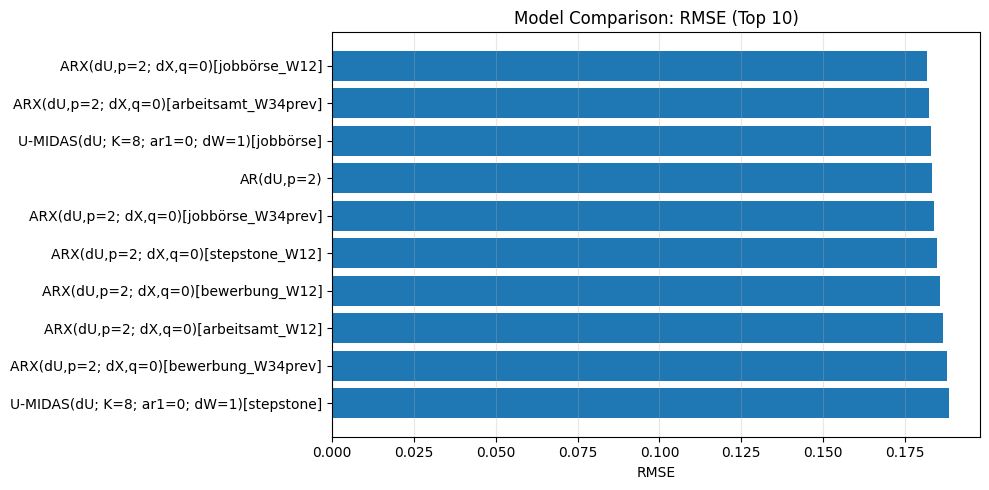

In [61]:
def plot_rmse_bar(leaderboard: pd.DataFrame, top_n: int = 10, title: str = None):
    top = leaderboard.head(top_n).iloc[::-1]
    plt.figure(figsize=(10, 5))
    plt.barh(top["model"], top["RMSE"])
    plt.xlabel("RMSE")
    plt.title(title or f"Model Comparison: RMSE (Top {top_n})")
    plt.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()

plot_rmse_bar(leaderboard, top_n=10)


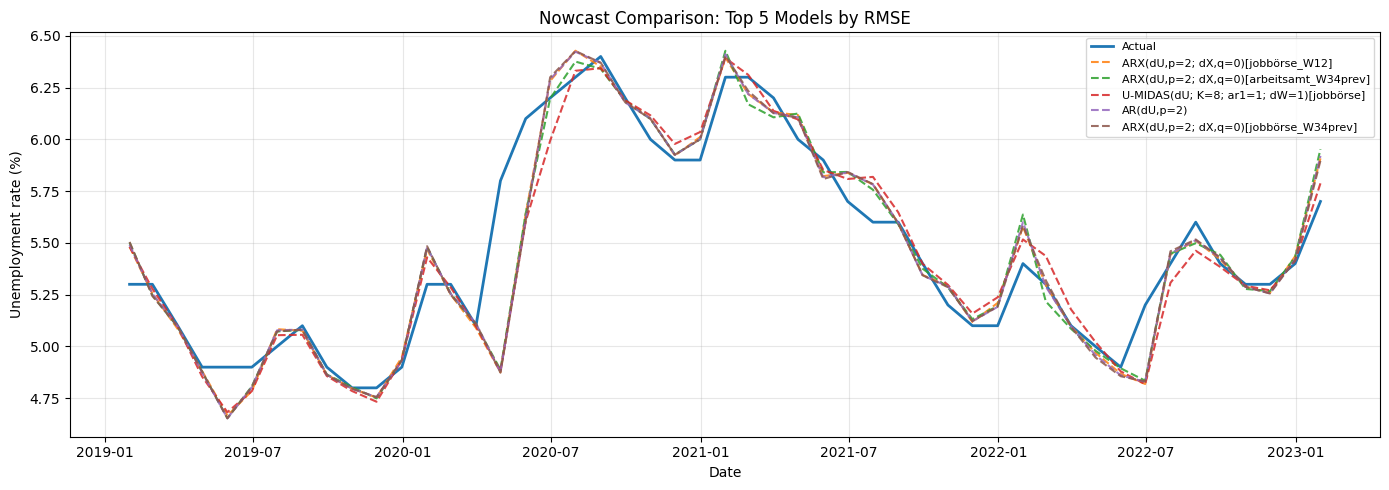

In [53]:
def plot_top_models(store: dict, leaderboard: pd.DataFrame, top_k: int = 5, title: str = None):
    top_models = leaderboard.head(top_k)["model"].tolist()
    base_act = store[top_models[0]]["act"]

    df = pd.DataFrame({"Actual": base_act})
    for m in top_models:
        df[m] = store[m]["pred"].reindex(base_act.index)

    plt.figure(figsize=(14, 5))
    plt.plot(df.index, df["Actual"], linewidth=2, label="Actual")
    for m in top_models:
        plt.plot(df.index, df[m], linestyle="--", label=m, alpha=0.85)
    plt.title(title or f"Nowcast Comparison: Top {top_k} Models by RMSE")
    plt.xlabel("Date"); plt.ylabel("Unemployment rate (%)")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

plot_top_models(store, leaderboard, top_k=5)

## Taken a look at the diagnostics


Model: ARX(dU,p=2; dX,q=0)[jobbörse_W12]
                pred  act       err   abs_err  month
2019-01-31  5.481580  5.3  0.181580  0.181580      1
2019-02-28  5.255350  5.3 -0.044650  0.044650      2
2019-03-31  5.084537  5.1 -0.015463  0.015463      3

Worst errors:
                pred  act       err   abs_err  month
2020-04-30  4.874972  5.8 -0.925028  0.925028      4
2020-05-31  5.639747  6.1 -0.460253  0.460253      5
2022-06-30  4.818600  5.2 -0.381400  0.381400      6
2019-05-31  4.665895  4.9 -0.234105  0.234105      5
2023-01-31  5.908379  5.7  0.208379  0.208379      1
2021-07-31  5.782954  5.6  0.182954  0.182954      7
2019-01-31  5.481580  5.3  0.181580  0.181580      1
2022-01-31  5.578627  5.4  0.178627  0.178627      1
2020-01-31  5.468760  5.3  0.168760  0.168760      1
2021-06-30  5.838046  5.7  0.138046  0.138046      6


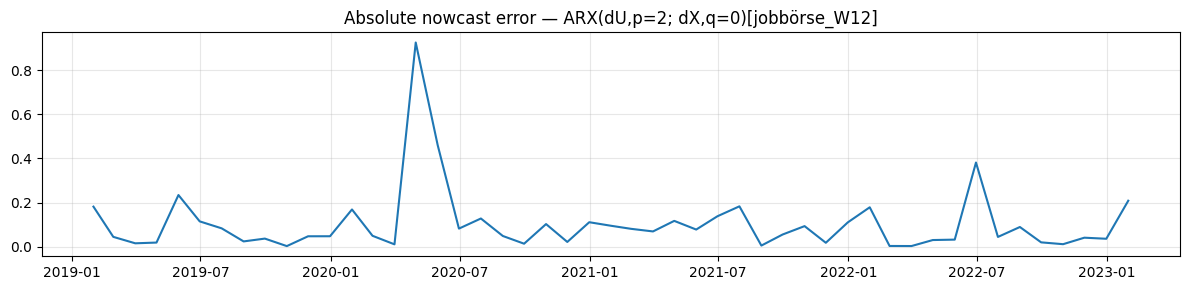


RMSE by month:
month
1     0.170742
2     0.052502
3     0.035916
4     0.466543
5     0.261592
6     0.214729
7     0.121150
8     0.052307
9     0.035319
10    0.069585
11    0.034259
12    0.083670
Name: err, dtype: float64


['ARX(dU,p=2; dX,q=0)[jobbörse_W12]',
 'ARX(dU,p=2; dX,q=0)[stepstone_W12]',
 'ARX(dU,p=2; dX,q=0)[bewerbung_W12]',
 'ARX(dU,p=2; dX,q=0)[arbeitsamt_W12]',
 'ARX(dU,p=2; dX,q=0)[indeed_W12]']

In [54]:
def diagnostics(model_name: str, store: dict, top_n: int = 10):
    pred = store[model_name]["pred"]
    act  = store[model_name]["act"]
    err  = store[model_name]["err"]

    df_eval = pd.concat([pred.rename("pred"), act.rename("act")], axis=1).dropna()
    df_eval["err"] = df_eval["pred"] - df_eval["act"]
    df_eval["abs_err"] = df_eval["err"].abs()
    df_eval["month"] = df_eval.index.month

    print(f"\nModel: {model_name}")
    print(df_eval.head(3))

    print("\nWorst errors:")
    print(df_eval.sort_values("abs_err", ascending=False).head(top_n))

    # abs error over time
    plt.figure(figsize=(12, 3))
    plt.plot(df_eval.index, df_eval["abs_err"])
    plt.title(f"Absolute nowcast error — {model_name}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # RMSE by month
    rmse_by_month = df_eval.groupby("month")["err"].apply(lambda x: float(np.sqrt(np.mean(x**2))))
    print("\nRMSE by month:")
    print(rmse_by_month)

# Example: best model
best_model = leaderboard.loc[0, "model"]
diagnostics(best_model, store)


def list_models(leaderboard, contains: str = ""):
    s = leaderboard["model"]
    if contains:
        s = s[s.str.contains(contains, case=False, regex=False)]
    return s.tolist()

list_models(leaderboard, contains="W12")[:10]


## Diagnostics for the best models

In [55]:
top_models = leaderboard.head(3)["model"].tolist()



Model: ARX(dU,p=2; dX,q=0)[jobbörse_W12]
                pred  act       err   abs_err  month
2019-01-31  5.481580  5.3  0.181580  0.181580      1
2019-02-28  5.255350  5.3 -0.044650  0.044650      2
2019-03-31  5.084537  5.1 -0.015463  0.015463      3

Worst errors:
                pred  act       err   abs_err  month
2020-04-30  4.874972  5.8 -0.925028  0.925028      4
2020-05-31  5.639747  6.1 -0.460253  0.460253      5
2022-06-30  4.818600  5.2 -0.381400  0.381400      6
2019-05-31  4.665895  4.9 -0.234105  0.234105      5
2023-01-31  5.908379  5.7  0.208379  0.208379      1
2021-07-31  5.782954  5.6  0.182954  0.182954      7
2019-01-31  5.481580  5.3  0.181580  0.181580      1
2022-01-31  5.578627  5.4  0.178627  0.178627      1
2020-01-31  5.468760  5.3  0.168760  0.168760      1
2021-06-30  5.838046  5.7  0.138046  0.138046      6


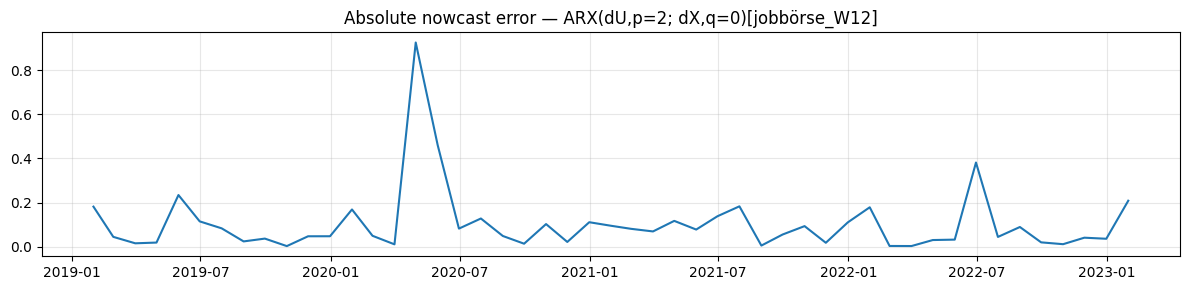


RMSE by month:
month
1     0.170742
2     0.052502
3     0.035916
4     0.466543
5     0.261592
6     0.214729
7     0.121150
8     0.052307
9     0.035319
10    0.069585
11    0.034259
12    0.083670
Name: err, dtype: float64

Model: ARX(dU,p=2; dX,q=0)[arbeitsamt_W34prev]
                pred  act       err   abs_err  month
2019-01-31  5.501373  5.3  0.201373  0.201373      1
2019-02-28  5.246974  5.3 -0.053026  0.053026      2
2019-03-31  5.094292  5.1 -0.005708  0.005708      3

Worst errors:
                pred  act       err   abs_err  month
2020-04-30  4.887996  5.8 -0.912004  0.912004      4
2020-05-31  5.642682  6.1 -0.457318  0.457318      5
2022-06-30  4.834369  5.2 -0.365631  0.365631      6
2023-01-31  5.952527  5.7  0.252527  0.252527      1
2019-05-31  4.653559  4.9 -0.246441  0.246441      5
2022-01-31  5.636875  5.4  0.236875  0.236875      1
2019-01-31  5.501373  5.3  0.201373  0.201373      1
2020-01-31  5.479171  5.3  0.179171  0.179171      1
2021-07-31  5.756428

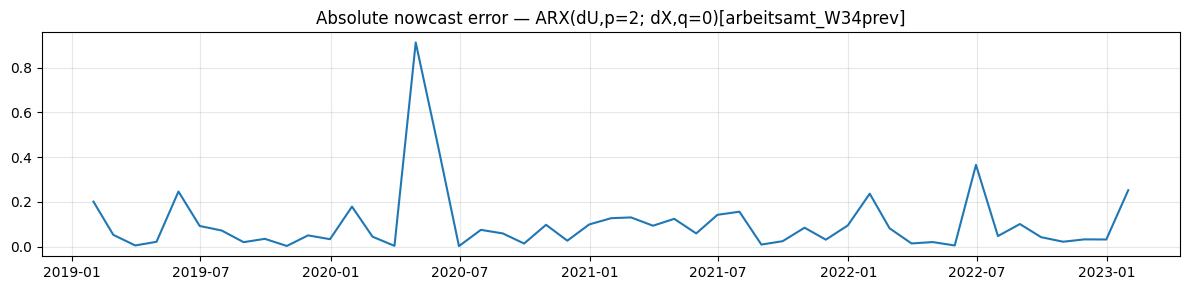


RMSE by month:
month
1     0.204345
2     0.084734
3     0.047636
4     0.460481
5     0.261454
6     0.201615
7     0.097045
8     0.059806
9     0.031136
10    0.065834
11    0.036669
12    0.072671
Name: err, dtype: float64

Model: U-MIDAS(dU; K=8; ar1=1; dW=1)[jobbörse]
                pred  act       err   abs_err  month
2019-01-31  5.481043  5.3  0.181043  0.181043      1
2019-02-28  5.278602  5.3 -0.021398  0.021398      2
2019-03-31  5.096094  5.1 -0.003906  0.003906      3

Worst errors:
                pred  act       err   abs_err  month
2020-04-30  4.881157  5.8 -0.918843  0.918843      4
2020-05-31  5.603772  6.1 -0.496228  0.496228      5
2022-06-30  4.817982  5.2 -0.382018  0.382018      6
2021-07-31  5.818644  5.6  0.218644  0.218644      7
2019-05-31  4.682338  4.9 -0.217662  0.217662      5
2020-06-30  5.993528  6.2 -0.206472  0.206472      6
2019-01-31  5.481043  5.3  0.181043  0.181043      1
2022-08-31  5.461981  5.6 -0.138019  0.138019      8
2021-12-31  5.237320

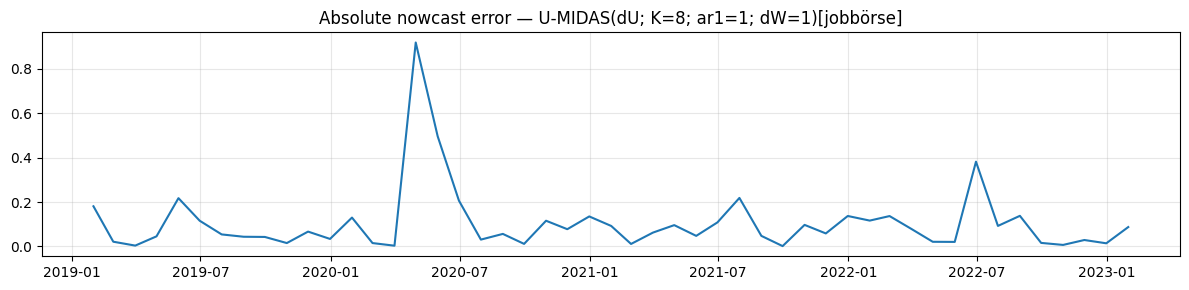


RMSE by month:
month
1     0.126072
2     0.069964
3     0.050319
4     0.462610
5     0.272174
6     0.231182
7     0.122764
8     0.081302
9     0.023646
10    0.076123
11    0.060898
12    0.098123
Name: err, dtype: float64


In [58]:
for m in leaderboard.head(3)["model"]:
    diagnostics(m, store)


## Comparison delta

In [64]:
def plot_delta_unemp(store: dict, models: list, title: str = None):
    # Choose a base actual series from the first model
    act = store[models[0]]["act"].dropna()
    dU_act = act.diff().rename("ΔUnemp_actual")

    df = pd.DataFrame({"ΔUnemp_actual": dU_act})
    for m in models:
        dU_pred = store[m]["pred"].reindex(act.index).diff().rename(f"ΔUnemp_{m}")
        df = df.join(dU_pred)

    df = df.dropna()

    plt.figure(figsize=(12, 4))
    plt.plot(df.index, df["ΔUnemp_actual"], label="ΔUnemployment (actual)", linewidth=2)
    for m in models:
        plt.plot(df.index, df[f"ΔUnemp_{m}"], linestyle="--", alpha=0.9, label=f"ΔUnemp ({m})")
    plt.title(title or "Predicted vs actual monthly changes (ΔUnemployment)")
    plt.xlabel("Date"); plt.ylabel("Δ unemployment (pp)")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


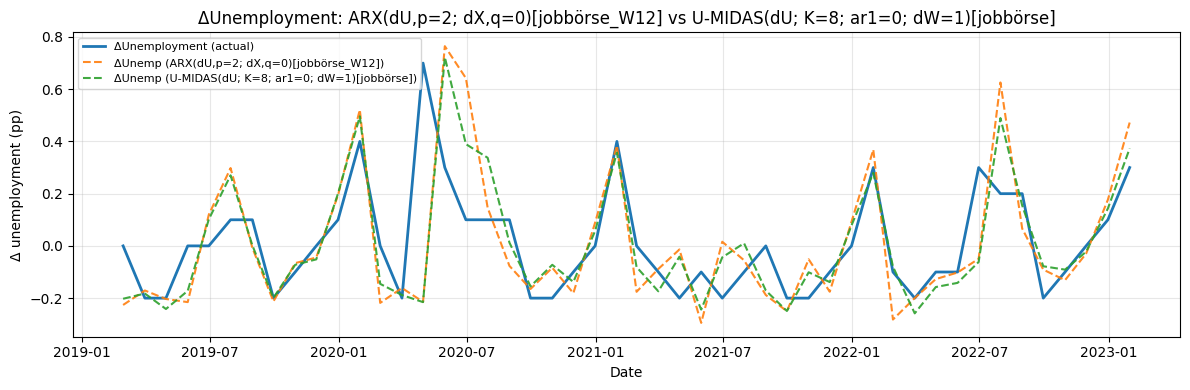

In [65]:
best_ar = leaderboard[leaderboard["model"].str.contains("^AR", regex=True)].iloc[0]["model"]
best_midas = leaderboard[leaderboard["model"].str.contains("UMIDAS|MIDAS", case=False, regex=True)].iloc[0]["model"]

plot_delta_unemp(
    store,
    models=[best_ar, best_midas],
    title=f"ΔUnemployment: {best_ar} vs {best_midas}"
)


## Biweekly comparison

In [71]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _extract_scheme_and_keyword(model_name: str):
    """
    Works for model names like:
      - 'ARX(dU,p=2; dX,q=0)[jobbörse_W12]'
      - 'ARX(dU,p=2; dX,q=0)[jobbörse_W34prev]'
      - 'ARX_jobbörse_W12_...'
      - 'ARX_jobbörse_W34prev_...'
    Returns (keyword, scheme) or (None, None).
    """
    if "W12" in model_name:
        scheme = "W12"
    elif "W34prev" in model_name:
        scheme = "W34prev"
    else:
        return None, None

    # Try to grab the part inside brackets [...] first
    m = re.search(r"\[(.*?)\]", model_name)
    token = m.group(1) if m else model_name

    # Remove obvious prefixes
    token = token.replace("ARX_", "").replace("ARX(dU,p=2; dX,q=0)", "")

    # Remove scheme suffixes
    token = token.replace("_W12", "").replace("_W34prev", "")

    # Cleanup leftover characters
    token = re.sub(r"[^\wäöüÄÖÜß]+", "", token)

    keyword = token if token else None
    return keyword, scheme


def list_arx_biweekly_models(leaderboard: pd.DataFrame):
    s = leaderboard["model"].astype(str)
    return leaderboard[s.str.contains("ARX", case=False) & (s.str.contains("W12") | s.str.contains("W34prev"))].copy()


In [72]:
def summarize_w12_vs_w34(leaderboard: pd.DataFrame) -> pd.DataFrame:
    arx = list_arx_biweekly_models(leaderboard).copy()
    if arx.empty:
        raise ValueError("No ARX biweekly models found in leaderboard['model'].")

    arx["keyword"], arx["scheme"] = zip(*arx["model"].map(_extract_scheme_and_keyword))
    arx = arx.dropna(subset=["keyword", "scheme"])

    # pivot RMSE per keyword
    pivot = (arx.pivot_table(index="keyword", columns="scheme", values="RMSE", aggfunc="min")
               .sort_index())

    # add delta columns when both exist
    if "W12" in pivot.columns and "W34prev" in pivot.columns:
        pivot["ΔRMSE(W12−W34prev)"] = pivot["W12"] - pivot["W34prev"]
        pivot = pivot.sort_values("ΔRMSE(W12−W34prev)")
    return pivot

biweekly_rmse = summarize_w12_vs_w34(leaderboard)
biweekly_rmse


scheme,W12,W34prev,ΔRMSE(W12−W34prev)
keyword,,,
stepstone,0.184628,0.189676,-0.005048
indeed,0.189497,0.193225,-0.003728
bewerbung,0.185653,0.187817,-0.002164
jobbörse,0.181685,0.183730,-0.002045
arbeitsamt,0.186491,0.182414,0.004077


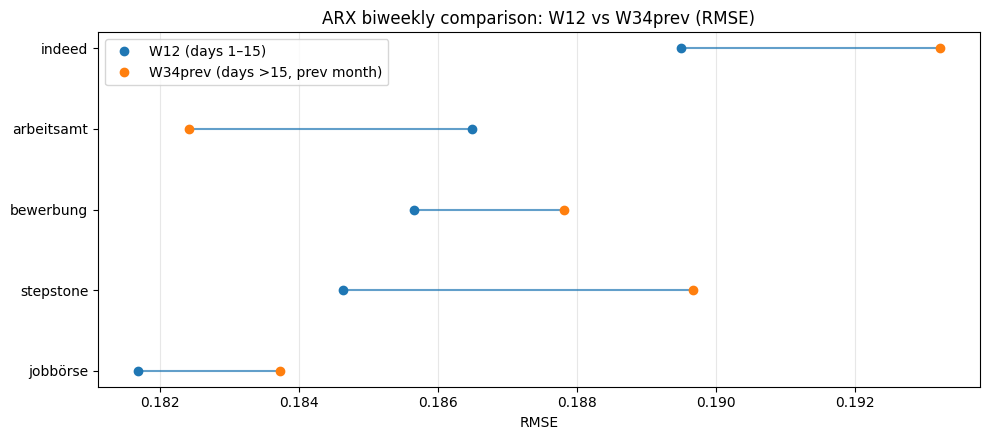

In [73]:
def plot_dumbbell_w12_w34(biweekly_rmse: pd.DataFrame, title: str = None):
    if not {"W12", "W34prev"}.issubset(biweekly_rmse.columns):
        raise ValueError("Need both W12 and W34prev columns in biweekly_rmse.")

    df = biweekly_rmse[["W12", "W34prev"]].dropna().copy()
    df = df.sort_values("W12")  # ordering choice; change if you want

    y = np.arange(len(df))
    plt.figure(figsize=(10, 0.5*len(df) + 2))
    plt.hlines(y=y, xmin=df["W12"], xmax=df["W34prev"], alpha=0.7)
    plt.plot(df["W12"], y, marker="o", linestyle="None", label="W12 (days 1–15)")
    plt.plot(df["W34prev"], y, marker="o", linestyle="None", label="W34prev (days >15, prev month)")

    plt.yticks(y, df.index)
    plt.xlabel("RMSE")
    plt.title(title or "ARX biweekly comparison: W12 vs W34prev (RMSE)")
    plt.grid(True, alpha=0.3, axis="x")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_dumbbell_w12_w34(biweekly_rmse)


In [74]:
def map_keyword_to_models(leaderboard: pd.DataFrame) -> pd.DataFrame:
    arx = list_arx_biweekly_models(leaderboard).copy()
    arx["keyword"], arx["scheme"] = zip(*arx["model"].map(_extract_scheme_and_keyword))
    arx = arx.dropna(subset=["keyword", "scheme"])

    # pick the best (lowest RMSE) model per keyword×scheme
    arx = arx.sort_values("RMSE").drop_duplicates(["keyword", "scheme"], keep="first")

    wide = arx.pivot(index="keyword", columns="scheme", values="model")
    return wide

kw_models = map_keyword_to_models(leaderboard)
kw_models


scheme,W12,W34prev
keyword,,
arbeitsamt,"ARX(dU,p=2; dX,q=0)[arbeitsamt_W12]","ARX(dU,p=2; dX,q=0)[arbeitsamt_W34prev]"
bewerbung,"ARX(dU,p=2; dX,q=0)[bewerbung_W12]","ARX(dU,p=2; dX,q=0)[bewerbung_W34prev]"
indeed,"ARX(dU,p=2; dX,q=0)[indeed_W12]","ARX(dU,p=2; dX,q=0)[indeed_W34prev]"
jobbörse,"ARX(dU,p=2; dX,q=0)[jobbörse_W12]","ARX(dU,p=2; dX,q=0)[jobbörse_W34prev]"
stepstone,"ARX(dU,p=2; dX,q=0)[stepstone_W12]","ARX(dU,p=2; dX,q=0)[stepstone_W34prev]"


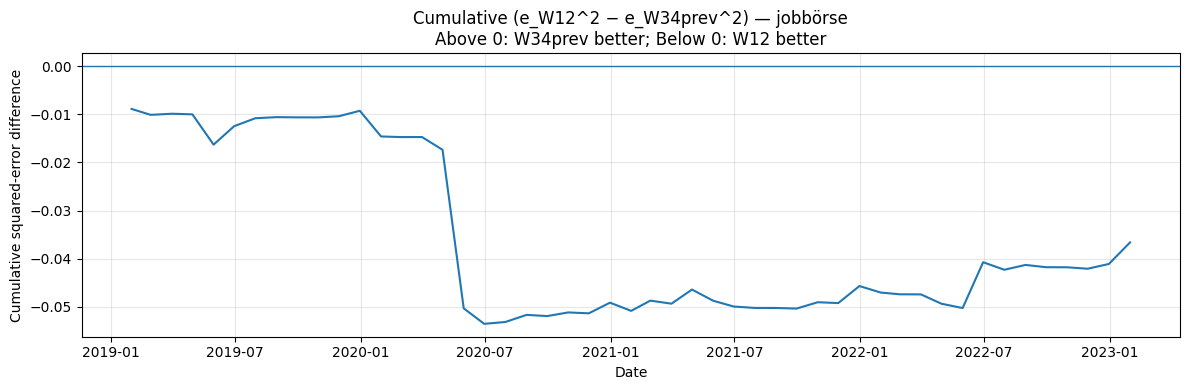

In [78]:
def plot_cum_sq_error_diff(keyword: str, store: dict, kw_models: pd.DataFrame):
    if keyword not in kw_models.index:
        raise ValueError(f"{keyword} not in kw_models.index")

    m12 = kw_models.loc[keyword].get("W12", None)
    m34 = kw_models.loc[keyword].get("W34prev", None)
    if pd.isna(m12) or pd.isna(m34):
        raise ValueError(f"Need both W12 and W34prev models for keyword={keyword}")

    e12 = store[m12]["err"].dropna()
    e34 = store[m34]["err"].dropna()
    idx = e12.index.intersection(e34.index)

    diff = (e12.loc[idx]**2 - e34.loc[idx]**2)  # >0 means W34prev better (lower loss)
    cum = diff.cumsum()

    plt.figure(figsize=(12,4))
    plt.plot(cum.index, cum.values)
    plt.axhline(0, linewidth=1)
    plt.title(f"Cumulative (e_W12^2 − e_W34prev^2) — {keyword}\nAbove 0: W34prev better; Below 0: W12 better")
    plt.xlabel("Date")
    plt.ylabel("Cumulative squared-error difference")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example:
plot_cum_sq_error_diff("jobbörse", store, kw_models)


In [81]:
import numpy as np
import pandas as pd
from scipy import stats

def _hac_var(x: np.ndarray, L: int) -> float:
    """
    Newey–West HAC variance estimator for the sample mean of x.
    Returns Var(mean(x)) = (gamma0 + 2*sum_{l=1..L} w_l * gamma_l) / T
    """
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    T = x.shape[0]
    if T <= 1:
        return np.nan

    gamma0 = np.dot(x, x) / T
    s = gamma0

    for l in range(1, L + 1):
        w = 1.0 - l / (L + 1.0)  # Bartlett weights
        gamma_l = np.dot(x[l:], x[:-l]) / T
        s += 2.0 * w * gamma_l

    return s / T  # variance of mean

def dm_test_paired(
    e1: pd.Series,
    e2: pd.Series,
    h: int = 1,
    loss: str = "mse",          # "mse" or "mae"
    hac_lags: int | None = None,
    small_sample: bool = True,
    alternative: str = "two-sided"  # "two-sided", "less", "greater"
) -> dict:
    """
    Diebold–Mariano test for equal predictive accuracy (paired forecasts).
    Compares model1 vs model2.

    d_t = L(e1_t) - L(e2_t)
    H0: E[d_t] = 0

    - If alternative="less":    E[d_t] < 0  -> model1 better (lower loss)
    - If alternative="greater": E[d_t] > 0  -> model2 better
    """
    # Align and drop missing
    df = pd.concat([e1.rename("e1"), e2.rename("e2")], axis=1).dropna()
    if df.shape[0] < 10:
        return {"T": df.shape[0], "dm_stat": np.nan, "pvalue": np.nan, "mean_d": np.nan}

    if loss.lower() == "mse":
        d = df["e1"].to_numpy()**2 - df["e2"].to_numpy()**2
    elif loss.lower() == "mae":
        d = np.abs(df["e1"].to_numpy()) - np.abs(df["e2"].to_numpy())
    else:
        raise ValueError("loss must be 'mse' or 'mae'.")

    T = d.shape[0]

    # HAC lag choice: for h=1, serial corr is often small; but allow user control.
    if hac_lags is None:
        # common safe default: h-1 (for multi-step). For nowcasting h=1 => 0.
        L = max(h - 1, 0)
    else:
        L = int(hac_lags)

    var_mean = _hac_var(d, L=L)
    if not np.isfinite(var_mean) or var_mean <= 0:
        return {"T": T, "dm_stat": np.nan, "pvalue": np.nan, "mean_d": float(np.mean(d))}

    dm = float(np.mean(d) / np.sqrt(var_mean))

    # Harvey–Leybourne–Newbold small-sample correction (widely used in applied work)
    if small_sample:
        # factor = sqrt((T + 1 - 2h + h(h-1)/T) / T)
        factor = np.sqrt((T + 1 - 2*h + (h*(h-1))/T) / T)
        dm = dm * factor

    # p-value using t distribution with T-1 df (common choice)
    dfree = T - 1
    if alternative == "two-sided":
        p = 2.0 * (1.0 - stats.t.cdf(abs(dm), df=dfree))
    elif alternative == "less":
        p = stats.t.cdf(dm, df=dfree)
    elif alternative == "greater":
        p = 1.0 - stats.t.cdf(dm, df=dfree)
    else:
        raise ValueError("alternative must be 'two-sided', 'less', or 'greater'.")

    return {
        "T": int(T),
        "mean_d": float(np.mean(d)),   # negative => model1 lower loss
        "dm_stat": float(dm),
        "pvalue": float(p),
        "hac_lags": int(L),
        "loss": loss.lower(),
        "h": int(h)
    }

def dm_biweekly_all_keywords(
    store: dict,
    kw_models: pd.DataFrame,
    h: int = 1,
    loss: str = "mse",
    hac_lags: int | None = None,
    alpha: float = 0.05
) -> pd.DataFrame:
    """
    Runs paired DM test per keyword: W12 vs W34prev.
    Uses errors from `store[model_name]['err']`.
    """
    rows = []
    for keyword in kw_models.index:
        m12 = kw_models.loc[keyword].get("W12", None)
        m34 = kw_models.loc[keyword].get("W34prev", None)

        if pd.isna(m12) or pd.isna(m34) or (m12 not in store) or (m34 not in store):
            continue

        e12 = store[m12]["err"]
        e34 = store[m34]["err"]

        res = dm_test_paired(
            e1=e12,
            e2=e34,
            h=h,
            loss=loss,
            hac_lags=hac_lags,
            small_sample=True,
            alternative="two-sided"
        )

        # Interpretation:
        # d = L(e_W12) - L(e_W34prev)
        # mean_d < 0 => W12 has LOWER average loss => W12 better
        if np.isfinite(res["mean_d"]):
            winner = "W12" if res["mean_d"] < 0 else "W34prev"
        else:
            winner = None

        rows.append({
            "keyword": keyword,
            "model_W12": m12,
            "model_W34prev": m34,
            **res,
            "winner_by_mean_loss": winner,
            "reject_equal_accuracy": bool(np.isfinite(res["pvalue"]) and (res["pvalue"] < alpha))
        })

    out = pd.DataFrame(rows).sort_values(["pvalue", "keyword"]).reset_index(drop=True)
    return out

# ---- RUN: DM tests for all keywords ----
dm_results_mse = dm_biweekly_all_keywords(
    store=store,
    kw_models=kw_models,
    h=1,
    loss="mse",
    hac_lags=0,     # for nowcasting (h=1) this is a reasonable default
    alpha=0.05
)

dm_results_mse


,keyword,model_W12,model_W34prev,T,mean_d,dm_stat,pvalue,hac_lags,loss,h,winner_by_mean_loss,reject_equal_accuracy
0,stepstone,"ARX(dU,p=2; dX,q=0)[stepstone_W12]","ARX(dU,p=2; dX,q=0)[stepstone_W34prev]",49,-0.001889,-1.347686,0.184086,0,mse,1,W12,False
1,jobbörse,"ARX(dU,p=2; dX,q=0)[jobbörse_W12]","ARX(dU,p=2; dX,q=0)[jobbörse_W34prev]",49,-0.000747,-0.964300,0.339729,0,mse,1,W12,False
2,arbeitsamt,"ARX(dU,p=2; dX,q=0)[arbeitsamt_W12]","ARX(dU,p=2; dX,q=0)[arbeitsamt_W34prev]",49,0.001504,0.924893,0.359648,0,mse,1,W34prev,False
3,bewerbung,"ARX(dU,p=2; dX,q=0)[bewerbung_W12]","ARX(dU,p=2; dX,q=0)[bewerbung_W34prev]",49,-0.000808,-0.390100,0.698188,0,mse,1,W12,False
4,indeed,"ARX(dU,p=2; dX,q=0)[indeed_W12]","ARX(dU,p=2; dX,q=0)[indeed_W34prev]",49,-0.001427,-0.380178,0.705490,0,mse,1,W12,False


In [82]:
dm_results_mae = dm_biweekly_all_keywords(
    store=store,
    kw_models=kw_models,
    h=1,
    loss="mae",
    hac_lags=0,
    alpha=0.05
)

dm_results_mae


,keyword,model_W12,model_W34prev,T,mean_d,dm_stat,pvalue,hac_lags,loss,h,winner_by_mean_loss,reject_equal_accuracy
0,bewerbung,"ARX(dU,p=2; dX,q=0)[bewerbung_W12]","ARX(dU,p=2; dX,q=0)[bewerbung_W34prev]",49,-0.004459,-1.412302,0.164312,0,mae,1,W12,False
1,stepstone,"ARX(dU,p=2; dX,q=0)[stepstone_W12]","ARX(dU,p=2; dX,q=0)[stepstone_W34prev]",49,-0.002144,-0.729810,0.469053,0,mae,1,W12,False
2,jobbörse,"ARX(dU,p=2; dX,q=0)[jobbörse_W12]","ARX(dU,p=2; dX,q=0)[jobbörse_W34prev]",49,-0.001225,-0.714087,0.478632,0,mae,1,W12,False
3,indeed,"ARX(dU,p=2; dX,q=0)[indeed_W12]","ARX(dU,p=2; dX,q=0)[indeed_W34prev]",49,0.003653,0.674661,0.503128,0,mae,1,W34prev,False
4,arbeitsamt,"ARX(dU,p=2; dX,q=0)[arbeitsamt_W12]","ARX(dU,p=2; dX,q=0)[arbeitsamt_W34prev]",49,0.001250,0.297889,0.767073,0,mae,1,W34prev,False
